In [1]:
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter, find_peaks

In [2]:
from scipy.io import loadmat

mat_file = 'PV_example'
data = loadmat(mat_file+'.mat')


In [3]:
print(data.keys())  # See all variable names


dict_keys(['__header__', '__version__', '__globals__', 'c001_Time\x00\x00\x00\x98«\x02\x00', 'c002_Current_2\x00\x00', 'c003_Voltage_2\x00\x00', 'c004_Current_2\x00\x00', 'c005_Voltage_2\x00\x00', 'c006_Current_2\x00\x00', 'c007_Voltage_2\x00\x00', 'c008_Current_2\x00\x00', 'c009_Voltage_2\x00\x00', 'c010_Current_2\x00\x00', 'c011_Voltage_2\x00\x00', 'c012_Current_2\x00\x00', 'c013_Voltage_2\x00\x00', 'c014_Current_2\x00\x00', 'c015_Voltage_2\x00\x00', 'c016_Current_2\x00\x00', 'c017_Voltage_2\x00\x00', 'c018_Current_2\x00\x00', 'c019_Voltage_2\x00\x00', 'c020_Current_2\x00\x00', 'c021_Voltage_2\x00\x00', 'c022_Current_2\x00\x00', 'c023_Voltage_2\x00\x00', 'c024_Current_2\x00\x00', 'c025_Voltage_2\x00\x00', 'c026_Current_2\x00\x00', 'c027_Voltage_2\x00\x00', 'c028_Current_2\x00\x00', 'c029_Voltage_2\x00\x00', 'c030_Current_2\x00\x00', 'c031_Voltage_2\x00\x00', 'c032_Current_2\x00\x00', 'c033_Voltage_2\x00\x00', 'c034_Current_2\x00\x00', 'c035_Voltage_2\x00\x00', 'c036_Current_2\x00\x00

In [4]:
import scipy.io
import pandas as pd

# Load .mat file
mat = scipy.io.loadmat("PV_example.mat")

# Extract actual data (ignoring MATLAB's metadata keys)
data_key = [k for k in mat.keys() if not k.startswith('__')][0]

# Extract and flatten the data
data_array = mat[data_key].flatten()

# Convert to DataFrame
df = pd.DataFrame({'Time': data_array})

print(df.head(10))
print(len(df))


      Time
0  0.00002
1  0.00004
2  0.00006
3  0.00008
4  0.00010
5  0.00012
6  0.00014
7  0.00016
8  0.00018
9  0.00020
175000


In [5]:
import scipy.io as sio
import pandas as pd
import numpy as np

def mat_to_dataframe(mat_path: str) -> pd.DataFrame:
    """
    Load a .mat file and return a tidy DataFrame.

    ▸ Strips MATLAB’s housekeeping keys (__header__, __version__, __globals__).
    ▸ Removes any trailing NULL (\\x00) padding that LabChart / MATLAB sometimes
      add to field names.
    ▸ Converts each variable to a 1-D NumPy array and uses the cleaned field
      name as the column header.
    """
    mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)

    def clean_key(k: str) -> str:
        return k.split("\x00")[0]  # keep stuff before first NULL

    data = {
        clean_key(k): np.asarray(v)
        for k, v in mat.items()
        if not k.startswith("__")          # skip MATLAB metadata
    }

    # Basic sanity-check: make sure all vectors share the same length
    lengths = {k: len(v) for k, v in data.items()}
    if len(set(lengths.values())) != 1:
        raise ValueError(
            f"Vectors have differing lengths: {lengths}. "
            "You may need to inspect nested structs or ragged arrays."
        )

    return pd.DataFrame(data)

# ---------- usage ----------
df = mat_to_dataframe("PV_example.mat")
print(df.head())      # first few rows
print(df.shape)       # (rows, columns)
print()


   c001_Time  c002_Current_2  c003_Voltage_2  c004_Current_2  c005_Voltage_2  \
0    0.00002    5.861109e-13       -0.073818   -5.720373e-14       -0.073742   
1    0.00004    8.912960e-13       -0.073818    2.479814e-13       -0.073788   
2    0.00006   -6.346295e-13       -0.073840   -3.623888e-13       -0.073745   
3    0.00008    2.809258e-13       -0.073843    2.479814e-13       -0.073721   
4    0.00010   -6.346295e-13       -0.073852   -5.720373e-14       -0.073769   

   c006_Current_2  c007_Voltage_2  c008_Current_2  c009_Voltage_2  \
0   -3.494521e-13       -0.073840    2.459351e-13       -0.073858   
1   -4.426696e-14       -0.073885   -6.696202e-13       -0.073916   
2   -6.546371e-13       -0.073919   -5.924997e-14       -0.073946   
3   -4.426696e-14       -0.073928   -6.696202e-13       -0.073916   
4   -4.426696e-14       -0.073913    5.511202e-13       -0.073940   

   c010_Current_2  ...  c038_Current_2  c039_Voltage_2  c040_Current_2  \
0    2.071930e-13  ...    4.83

In [6]:
import scipy.io as sio
import numpy as np
import pandas as pd

def load_traces(mat_path: str, fs: int = 50_000):
    """Return:
       time_ms       – 1-D array of time (ms)
       currents_pA   – list[ np.ndarray ]  (one per sweep)
       voltages_mV   – list[ np.ndarray ]  (one per sweep)
    """
    def clean(k): return k.split("\x00")[0]        # trim padded NULLs
    m = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    df = pd.DataFrame({clean(k): np.asarray(v) for k, v in m.items()
                       if not k.startswith("__")})

    time_ms = df.filter(regex="Time").iloc[:, 0].values * 1_000
    cur_cols = sorted([c for c in df if "Current" in c],
                      key=lambda s: int(s.split('_')[0][1:]))
    volt_cols = sorted([c for c in df if "Voltage" in c],
                       key=lambda s: int(s.split('_')[0][1:]))

    currents  = [df[c].values * 1e12  for c in cur_cols]  # pA
    voltages  = [df[v].values * 1e3   for v in volt_cols] # mV
    return time_ms, currents, voltages, fs


In [7]:
def measure_iv(currents, voltages, fs, iv_start_ms=50, ss_window_ms=30):
    """Return a DataFrame with one row per sweep."""
    iv_start  = int(iv_start_ms * 1e-3 * fs)          # 50 ms marker
    ss_win    = int(ss_window_ms * 1e-3 * fs)         # last 30 ms

    steps_pA = []
    vm_ss_mV = []

    for I, V in zip(currents, voltages):
        # ignore −50 pA access-test (first 50 ms)
        step_val = np.mean(I[iv_start + int(10e-3*fs) : iv_start + int(20e-3*fs)])
        steps_pA.append(step_val)

        vm_ss    = np.mean(V[-ss_win:])               # end of sweep
        vm_ss_mV.append(vm_ss)

    return pd.DataFrame({"step_pA": steps_pA, "Vm_ss_mV": vm_ss_mV})


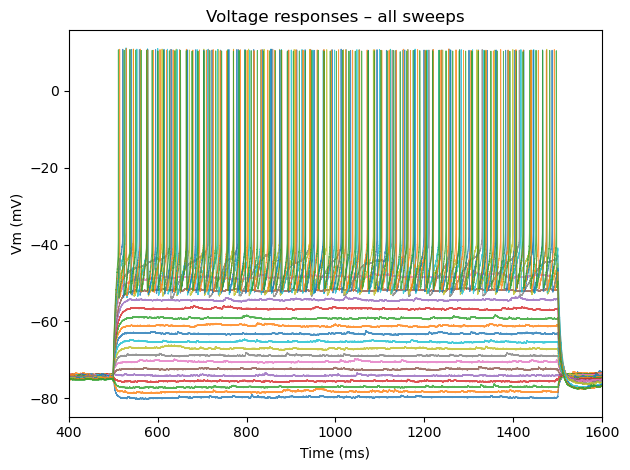

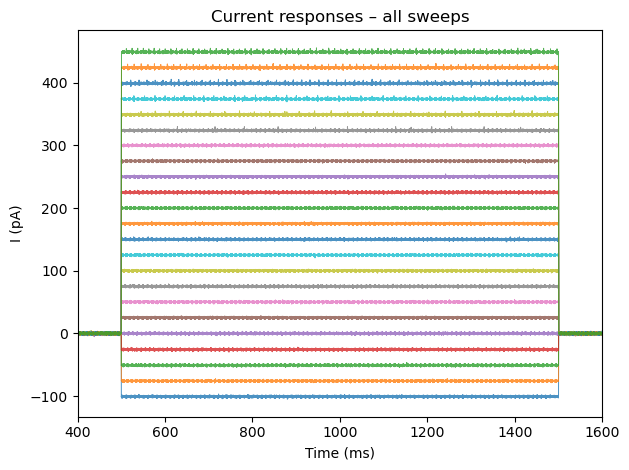

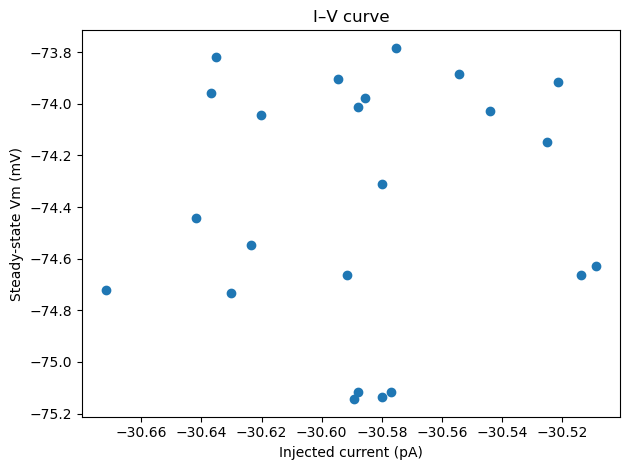

      step_pA   Vm_ss_mV
0  -30.575118 -73.783312
1  -30.636750 -73.956322
2  -30.554231 -73.883895
3  -30.585694 -73.976613
4  -30.587814 -74.010824
5  -30.635231 -73.818753
6  -30.620300 -74.044750
7  -30.521247 -73.913606
8  -30.525034 -74.146788
9  -30.594621 -73.902992
10 -30.544037 -74.026653
11 -30.641896 -74.444089
12 -30.580075 -74.309248
13 -30.623674 -74.547663
14 -30.508838 -74.626840
15 -30.591511 -74.664663
16 -30.513719 -74.661674
17 -30.630264 -74.733433
18 -30.671668 -74.722811
19 -30.576854 -75.117545
20 -30.579837 -75.137264
21 -30.587896 -75.116341
22 -30.589205 -75.144233


In [8]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
time_ms, I_traces, V_traces, fs = load_traces("PV_example.mat")
iv_df = measure_iv(I_traces, V_traces, fs)

# ---- (a) overlay all voltage traces --------------------------------
plt.figure()
for V in V_traces:
    plt.plot(time_ms, V, linewidth=0.7, alpha=0.8)
plt.xlim(400, 1600)
plt.xlabel("Time (ms)");  plt.ylabel("Vm (mV)")
plt.title("Voltage responses – all sweeps")
plt.tight_layout();  plt.show()

# ---- (b) overlay all current traces --------------------------------
plt.figure()
for I in I_traces:
    plt.plot(time_ms, I, linewidth=0.7, alpha=0.8)
plt.xlim(400, 1600)
plt.xlabel("Time (ms)");  plt.ylabel("I (pA)")
plt.title("Current responses – all sweeps")
plt.tight_layout();  plt.show()

# ---- (b) I–V (steady-state) ----------------------------------------
plt.figure()
plt.scatter(iv_df["step_pA"], iv_df["Vm_ss_mV"])
plt.xlabel("Injected current (pA)");  plt.ylabel("Steady-state Vm (mV)")
plt.title("I–V curve")
plt.tight_layout();  plt.show()

print(iv_df)          # table of numeric values


In [9]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
#  A.  LOAD THE FILE  →  time_ms, currents, voltages
# ------------------------------------------------------------------
def load_traces(mat_path, fs=50_000):
    def clean(k): return k.split("\x00")[0]
    m  = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    df = pd.DataFrame({clean(k): np.asarray(v) for k, v in m.items()
                       if not k.startswith("__")})
    time_ms = df.filter(regex="Time").iloc[:, 0].values * 1_000

    cur_cols  = sorted([c for c in df if "Current" in c],
                       key=lambda s: int(s.split('_')[0][1:]))
    volt_cols = sorted([c for c in df if "Voltage" in c],
                       key=lambda s: int(s.split('_')[0][1:]))

    currents = [df[c].values * 1e12  for c in cur_cols]   # pA
    voltages = [df[c].values * 1e3   for c in volt_cols]  # mV
    return time_ms, currents, voltages, fs

# ------------------------------------------------------------------
#  B.  FIGURE OUT HOW BIG EACH IV STEP WAS
# ------------------------------------------------------------------
def injected_steps_pA(currents, fs,
                      iv_start_ms=50, sample_ms=(60, 70)):
    """Return a list of step amplitudes (pA), one per sweep."""
    i0 = int((iv_start_ms + sample_ms[0]) * 1e-3 * fs)
    i1 = int((iv_start_ms + sample_ms[1]) * 1e-3 * fs)
    return [np.mean(I[i0:i1]) for I in currents]

# ------------------------------------------------------------------
#  C.  STEADY-STATE MEMBRANE VOLTAGE FOR EACH SWEEP
# ------------------------------------------------------------------
def steady_state_vm(voltages, fs, ss_window_ms=30):
    n_end = int(ss_window_ms * 1e-3 * fs)
    return [np.mean(V[-n_end:]) for V in voltages]

# ------------------------------------------------------------------
#  D.  RUN IT
# ------------------------------------------------------------------
time_ms, I_traces, V_traces, fs = load_traces("PV_example.mat")

step_pA   = injected_steps_pA(I_traces, fs)          # list like [-100, -75, ...]
Vm_ss_mV  = steady_state_vm(V_traces, fs)

summary   = pd.DataFrame({"step_pA": step_pA,
                          "Vm_ss_mV": Vm_ss_mV})
print(summary.head())


    step_pA   Vm_ss_mV
0 -0.058440 -73.783312
1  0.020924 -73.956322
2 -0.058305 -73.883895
3 -0.065964 -73.976613
4 -0.010709 -74.010824


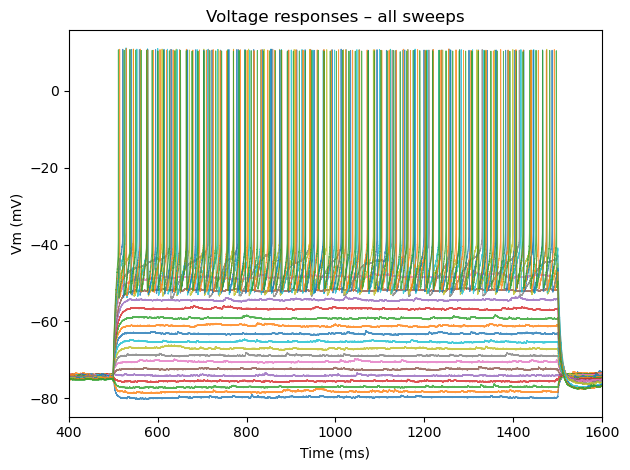

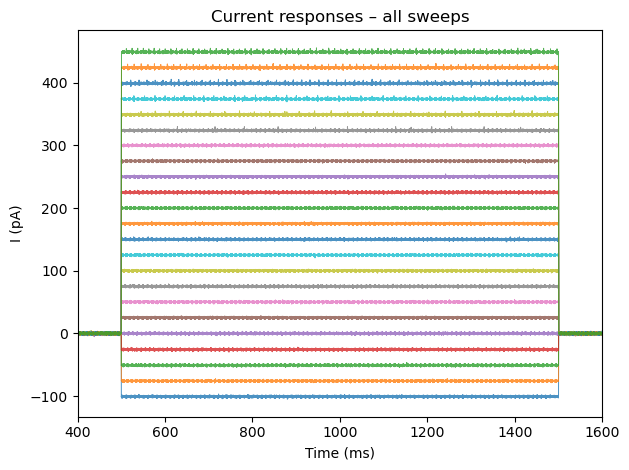

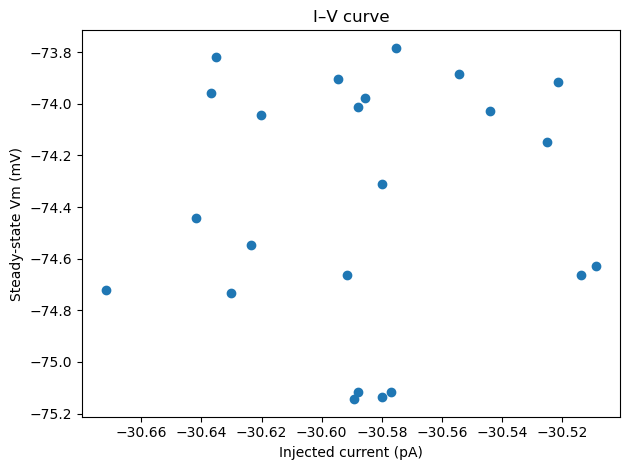

      step_pA   Vm_ss_mV
0  -30.575118 -73.783312
1  -30.636750 -73.956322
2  -30.554231 -73.883895
3  -30.585694 -73.976613
4  -30.587814 -74.010824
5  -30.635231 -73.818753
6  -30.620300 -74.044750
7  -30.521247 -73.913606
8  -30.525034 -74.146788
9  -30.594621 -73.902992
10 -30.544037 -74.026653
11 -30.641896 -74.444089
12 -30.580075 -74.309248
13 -30.623674 -74.547663
14 -30.508838 -74.626840
15 -30.591511 -74.664663
16 -30.513719 -74.661674
17 -30.630264 -74.733433
18 -30.671668 -74.722811
19 -30.576854 -75.117545
20 -30.579837 -75.137264
21 -30.587896 -75.116341
22 -30.589205 -75.144233


In [10]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
time_ms, I_traces, V_traces, fs = load_traces("PV_example.mat")
iv_df = measure_iv(I_traces, V_traces, fs)

# ---- (a) overlay all voltage traces --------------------------------
plt.figure()
for V in V_traces:
    plt.plot(time_ms, V, linewidth=0.7, alpha=0.8)
plt.xlim(400, 1600)
plt.xlabel("Time (ms)");  plt.ylabel("Vm (mV)")
plt.title("Voltage responses – all sweeps")
plt.tight_layout();  plt.show()

# ---- (b) overlay all current traces --------------------------------
plt.figure()
for I in I_traces:
    plt.plot(time_ms, I, linewidth=0.7, alpha=0.8)
plt.xlim(400, 1600)
plt.xlabel("Time (ms)");  plt.ylabel("I (pA)")
plt.title("Current responses – all sweeps")
plt.tight_layout();  plt.show()

# ---- (b) I–V (steady-state) ----------------------------------------
plt.figure()
plt.scatter(iv_df["step_pA"], iv_df["Vm_ss_mV"])
plt.xlabel("Injected current (pA)");  plt.ylabel("Steady-state Vm (mV)")
plt.title("I–V curve")
plt.tight_layout();  plt.show()

print(iv_df)          # table of numeric values


/tmp/ipykernel_2727935/1024989552.py:6: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout();  plt.show()
/home/hrbncv/miniconda3/envs/BMTK/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


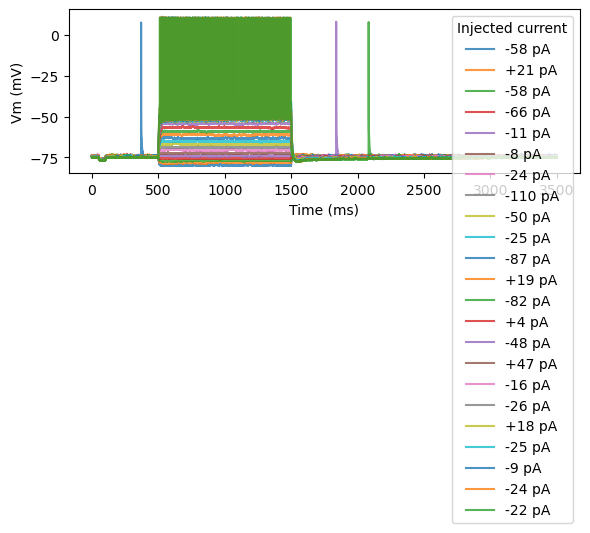

In [11]:
plt.figure(figsize=(6,4))
for step, V in zip(step_pA, V_traces):
    plt.plot(time_ms, V, label=f"{step*1e3:+.0f} pA", alpha=0.8)
plt.legend(title="Injected current")
plt.xlabel("Time (ms)");  plt.ylabel("Vm (mV)")
plt.tight_layout();  plt.show()


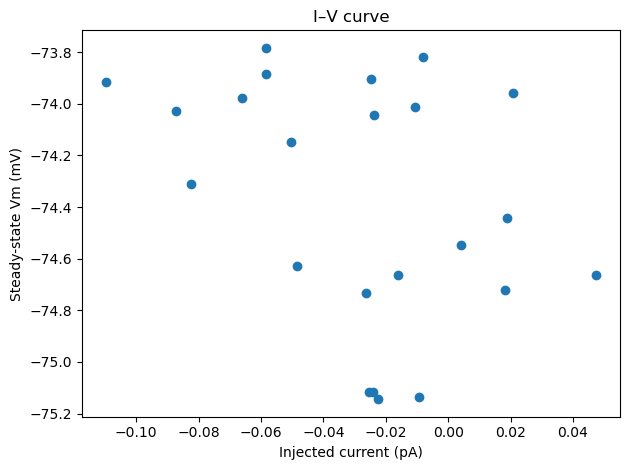

In [12]:
plt.figure()
plt.scatter(summary["step_pA"], summary["Vm_ss_mV"])
plt.xlabel("Injected current (pA)")
plt.ylabel("Steady-state Vm (mV)")
plt.title("I–V curve")
plt.tight_layout();  plt.show()


In [13]:
long = pd.concat(
    [pd.DataFrame({"time_ms": time_ms,
                   "Vm_mV":   V,
                   "I_pA":    I,
                   "step_pA": step})
     for V, I, step in zip(V_traces, I_traces, step_pA)]
)
# long now has columns: time_ms, Vm_mV, I_pA, step_pA


<Axes: xlabel='time_ms', ylabel='Vm_mV'>

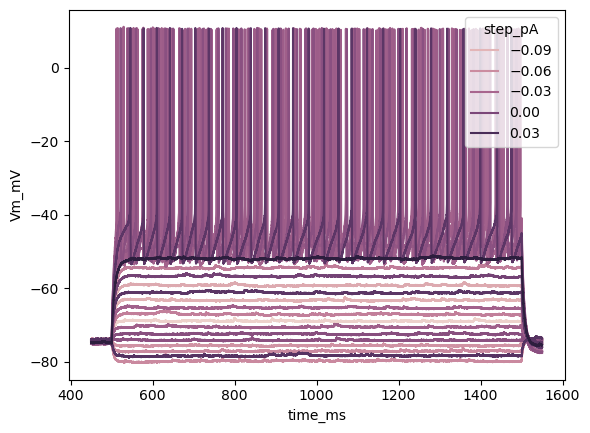

In [14]:
import seaborn as sns
sns.lineplot(data=long.query("450 < time_ms < 1550"),       # first 200 ms
             x="time_ms", y="Vm_mV", hue="step_pA",
             estimator=None)


In [15]:
results = []
for cell, fname in [("SST", "SST_example.mat"),
                    ("PV",  "PV_example.mat"),
                    ("PYR", "PyrExample.mat")]:
    _, I, V, fs = load_traces(fname)
    steps  = injected_steps_pA(I, fs)
    vm_ss  = steady_state_vm(V, fs)
    res    = pd.DataFrame({"cell": cell,
                           "step_pA": steps,
                           "Vm_ss_mV": vm_ss})
    results.append(res)

all_cells = pd.concat(results, ignore_index=True)


In [16]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_mat(mat_path):
    """Return time (ms), list[curr traces], list[Vm traces]."""
    def clean(k): return k.split("\x00")[0]
    m  = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    df = pd.DataFrame({clean(k): np.asarray(v) for k, v in m.items()
                       if not k.startswith("__")})
    time_ms   = df.filter(regex="Time").iloc[:, 0].values * 1_000
    cur_cols  = sorted([c for c in df if "Current" in c],
                       key=lambda s: int(s.split('_')[0][1:]))
    volt_cols = sorted([c for c in df if "Voltage" in c],
                       key=lambda s: int(s.split('_')[0][1:]))
    currents  = [df[c].values * 1e12 for c in cur_cols]   # → pA
    voltages  = [df[c].values * 1e3  for c in volt_cols]  # → mV
    return time_ms, currents, voltages

def estimate_step_pA(I_trace, thr=0.7):
    """
    Guess the injected-current plateau amplitude (pA).

    1. Find |I|max.
    2. Grab every sample with |I| ≥ thr·|I|max (thr=0.7 by default).
    3. Average those points – yields the flat part of the IV step.
    """
    vmax = np.max(np.abs(I_trace))
    idx  = np.abs(I_trace) >= thr * vmax
    return float(np.mean(I_trace[idx]))

def plot_range(mat_path, low_pA=-np.inf, high_pA=np.inf, *,
               thr=0.7, legend=True):
    """Plot only sweeps whose estimated step lies in [low_pA, high_pA]."""
    time_ms, I_list, V_list = load_mat(mat_path)

    # estimate amplitude for every sweep
    step_pA = [estimate_step_pA(I, thr) for I in I_list]

    # choose sweeps in range
    keep = [low_pA <= s <= high_pA for s in step_pA]

    if not any(keep):
        print(f"No sweeps between {low_pA} and {high_pA} pA.")
        return

    plt.figure(figsize=(6, 4))
    for keep_flag, V, step in zip(keep, V_list, step_pA):
        if not keep_flag:
            continue
        plt.plot(time_ms, V, lw=0.8, alpha=0.85,
                 label=f"{step:+.0f} pA" if legend else None)

    plt.xlabel("Time (ms)")
    plt.ylabel("Vm (mV)")
    plt.title(f"Traces with {low_pA} ≤ I ≤ {high_pA} pA")
    if legend:
        plt.legend(title="Injected current")
    plt.tight_layout()
    plt.show()


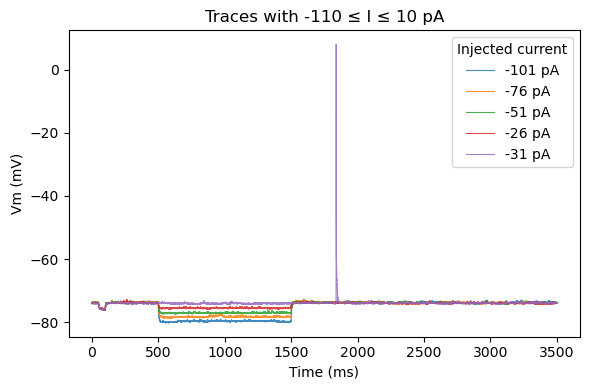

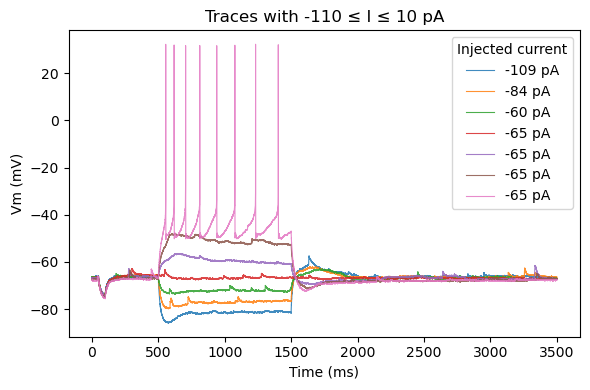

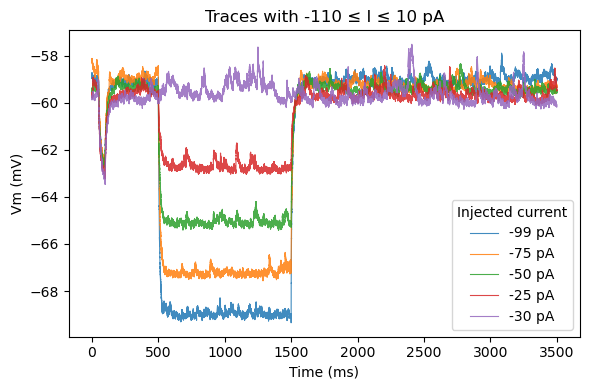

In [17]:
# Plot only +100 pA to +200 pA sweeps
plot_range("PV_example.mat", -110, 10)

# Hyperpolarizing band –200 pA to –75 pA
plot_range("SST_example.mat", -110, 10)

# Everything depolarizing ≥ +250 pA
plot_range("PyrExample.mat", -110, 10)


In [18]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FS = 50_000                     # sampling rate (Hz)
IDX_1000MS = int(1.000 * FS)    # sample index at 1000 ms
STEP_GRID = np.arange(-100, 325, 25)   # −100, −75, … +300 pA

def load_currents_voltages(mat_path):
    """Return time (ms), list[curr traces in pA], list[Vm traces in mV]."""
    def clean(k): return k.split("\x00")[0]
    m  = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    df = pd.DataFrame({clean(k): np.asarray(v) for k, v in m.items()
                       if not k.startswith("__")})
    time_ms   = df.filter(regex="Time").iloc[:, 0].values * 1_000

    cur_cols  = sorted([c for c in df if "Current" in c],
                       key=lambda s: int(s.split('_')[0][1:]))
    volt_cols = sorted([c for c in df if "Voltage" in c],
                       key=lambda s: int(s.split('_')[0][1:]))

    currents  = [df[c].values * 1e12 for c in cur_cols]   # → pA
    voltages  = [df[c].values * 1e3  for c in volt_cols]  # → mV
    return time_ms, currents, voltages

def label_by_single_point(currents, idx=IDX_1000MS):
    """
    For every current trace, read the value at idx (default 1000 ms),
    round to nearest 25 pA, and return the list of step labels.
    """
    raw = [I[idx] for I in currents]
    rounded = [25 * round(val / 25) for val in raw]       # snap to grid
    return rounded

def plot_range(mat_path, low_pA=-np.inf, high_pA=np.inf, *, legend=True):
    """Plot sweeps whose IV-step (rounded to grid) lies in [low, high] pA."""
    time_ms, I_traces, V_traces = load_currents_voltages(mat_path)
    step_pA = label_by_single_point(I_traces)             # list like −100,−75 …
    # step_pA = [-100 + 25*i for i in range(len(I_traces))] # if known -100 + 25x

    keep = [low_pA <= s <= high_pA for s in step_pA]
    if not any(keep):
        print(f"No sweeps between {low_pA} and {high_pA} pA")
        return

    plt.figure(figsize=(6,4))
    for V, step, flag in zip(V_traces, step_pA, keep):
        if not flag:
            continue
        plt.plot(time_ms, V, lw=0.8, alpha=0.85,
                 label=f"{step:+.0f} pA" if legend else None)

    plt.xlabel("Time (ms)")
    plt.ylabel("Vm (mV)")
    plt.title(f"Traces with {low_pA} ≤ I ≤ {high_pA} pA")
    if legend:
        plt.legend(title="Injected current")
    plt.tight_layout()
    plt.show()


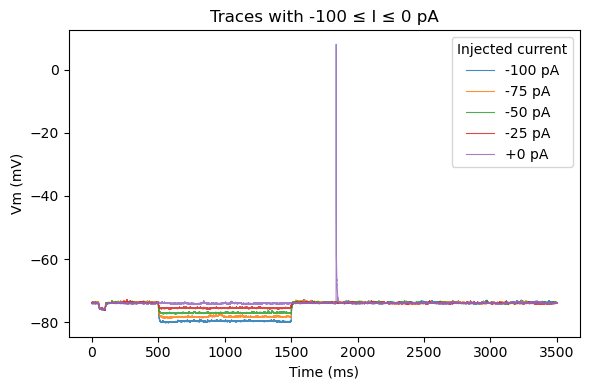

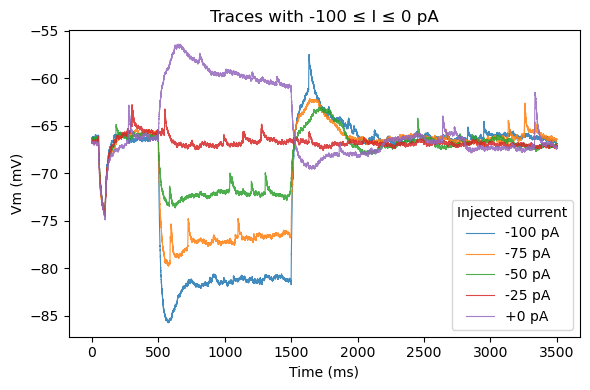

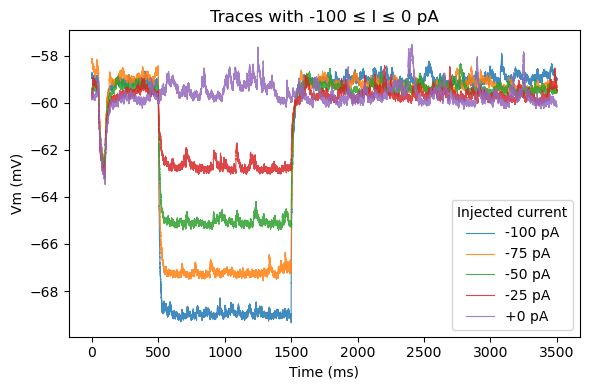

In [19]:
# Plot only +100 pA to +200 pA sweeps
plot_range("PV_example.mat", -100, 0)

# Hyperpolarizing band –200 pA to –75 pA
plot_range("SST_example.mat", -100, 0)

# Everything depolarizing ≥ +250 pA
plot_range("PyrExample.mat", -100, 0)


In [20]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- USER-TUNABLE CONSTANTS -----------------
FS          = 50_000                      # sampling rate (Hz)
IDX_1000MS  = int(1.000 * FS)             # sample index at 1000 ms
STEP_GRID   = np.arange(-100, 325, 25)    # expected step list −100…+300 pA
# ----------------------------------------------------------

def _clean(k): return k.split("\x00")[0]

def load_currents_voltages(mat_path):
    """Return time (ms) + lists of current (pA) & voltage (mV) traces."""
    m  = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    df = pd.DataFrame({_clean(k): np.asarray(v) for k, v in m.items()
                       if not k.startswith("__")})
    time_ms   = df.filter(regex="Time").iloc[:, 0].values * 1_000

    cur_cols  = sorted([c for c in df if "Current" in c],
                       key=lambda s: int(s.split('_')[0][1:]))
    volt_cols = sorted([c for c in df if "Voltage" in c],
                       key=lambda s: int(s.split('_')[0][1:]))

    currents  = [df[c].values * 1e12 for c in cur_cols]   # A → pA
    voltages  = [df[c].values * 1e3  for c in volt_cols]  # V → mV
    return time_ms, currents, voltages

def step_labels_by_point(currents, idx=IDX_1000MS):
    """Label each sweep by taking the value at 1000 ms and snapping to 25 pA."""
    return [25 * round(I[idx] / 25) for I in currents]

def plot_iv_sweeps(mat_path,
                   low_pA=-np.inf,
                   high_pA=np.inf,
                   *,
                   what="V",         # {"V", "I", "both"}
                   legend=True,
                   time_window=None  # tuple (tmin_ms, tmax_ms) or None
                   ):
    """
    Plot sweeps whose IV-step lies in [low_pA, high_pA].
    
    Parameters
    ----------
    what         : 'V' for voltage, 'I' for current, 'both' to overlay both.
    time_window  : (tmin_ms, tmax_ms) to zoom x-axis; None = full sweep.
    legend       : show / hide legend.
    """
    assert what in {"V", "I", "both"}, "`what` must be 'V', 'I', or 'both'"

    t_ms, I_traces, V_traces = load_currents_voltages(mat_path)
    step_pA = step_labels_by_point(I_traces)

    keep = [low_pA <= s <= high_pA for s in step_pA]
    if not any(keep):
        print(f"No sweeps between {low_pA} and {high_pA} pA")
        return

    plt.figure(figsize=(7, 4))
    for I, V, step, flag in zip(I_traces, V_traces, step_pA, keep):
        if not flag:
            continue
        label = f"{step:+.0f} pA" if legend else None
        if what in {"V", "both"}:
            plt.plot(t_ms,  V, lw=0.9, alpha=0.85, label=label if what=="V" else None)
        if what in {"I", "both"}:
            # Current in dashed style so it's distinguishable when overlaying
            plt.plot(t_ms,  I, lw=0.9, alpha=0.7, ls="--",
                     label=label if what=="I" else None)

    if time_window:
        plt.xlim(*time_window)

    plt.xlabel("Time (ms)")
    ylabel = {"V": "Membrane potential (mV)",
              "I": "Injected current (pA)",
              "both": "mV  /  pA (dashed)"}[what]
    plt.ylabel(ylabel)
    plt.title(f"Traces with {low_pA} ≤ I ≤ {high_pA} pA  ({what}-mode)")
    if legend:
        plt.legend(title="IV step")
    plt.tight_layout()
    plt.show()


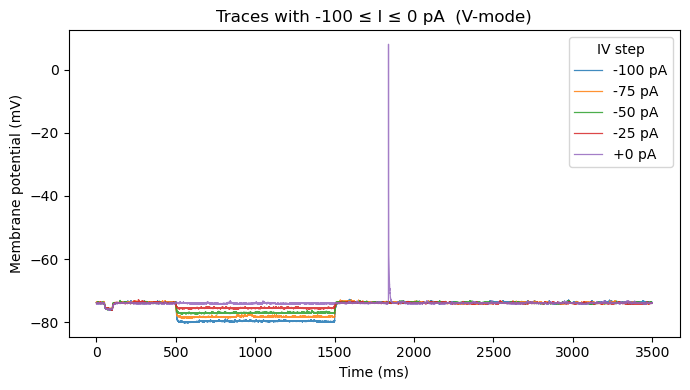

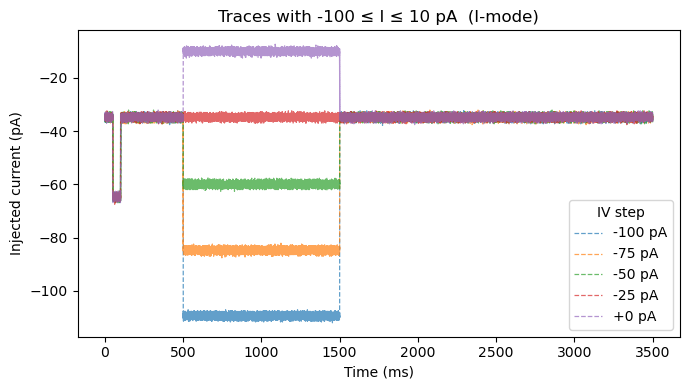

/tmp/ipykernel_2727935/1451681528.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="IV step")


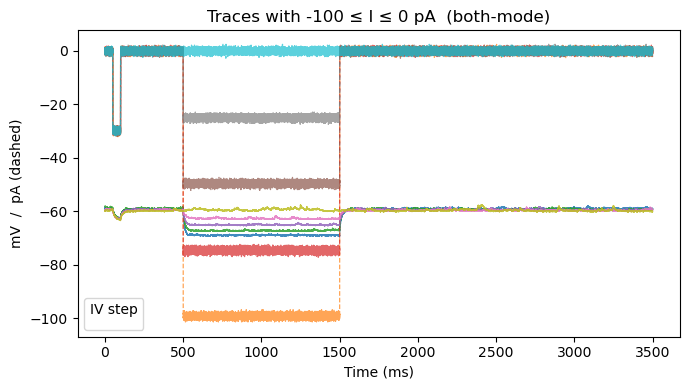

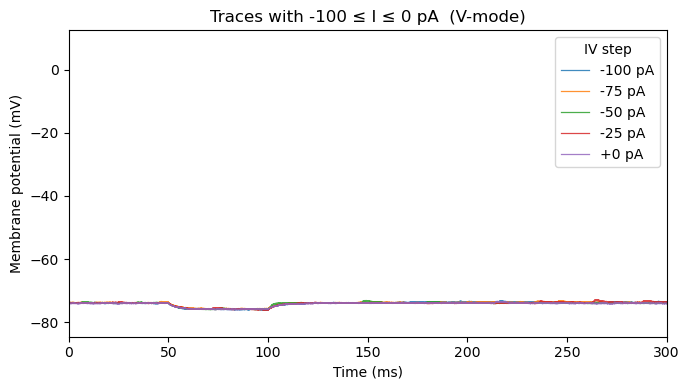

In [21]:
# Voltage only, +100 pA to +200 pA
plot_iv_sweeps("PV_example.mat", -100, 0, what="V")

# Current traces only, hyperpolarizing band −200 pA to −75 pA
plot_iv_sweeps("SST_example.mat", -100, 10, what="I")

# Overlay voltage (solid) and current (dashed) for big depolarizing steps ≥+250 pA
plot_iv_sweeps("PyrExample.mat", -100, 0, what="both")

# Zoom in: plot only 0–300 ms portion of voltage sweeps between −50 pA and +75 pA
plot_iv_sweeps("PV_example.mat", -100, 0, what="V", time_window=(0, 300))


In [22]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FS          = 50_000                       # Hz
IDX_1000MS  = int(1.000 * FS)              # 1000 ms sample
STEP_GRID   = np.arange(-100, 325, 25)     # −100 … +300 pA

def _clean(k): return k.split("\x00")[0]

def load_currents_voltages(mat_path):
    m  = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    df = pd.DataFrame({_clean(k): np.asarray(v) for k, v in m.items()
                       if not k.startswith("__")})

    time_ms   = df.filter(regex="Time").iloc[:, 0].values * 1_000
    cur_cols  = sorted([c for c in df if "Current" in c],
                       key=lambda s: int(s.split('_')[0][1:]))
    volt_cols = sorted([c for c in df if "Voltage" in c],
                       key=lambda s: int(s.split('_')[0][1:]))

    currents  = [df[c].values * 1e12 for c in cur_cols]   #  ➜ pA
    voltages  = [df[c].values * 1e3  for c in volt_cols]  #  ➜ mV
    return time_ms, currents, voltages

def step_labels_by_point(currents, idx=IDX_1000MS):
    return [25 * round(I[idx] / 25) for I in currents]

def plot_iv_sweeps(mat_path,
                   low_pA=-np.inf, high_pA=np.inf,
                   *, what="V", legend=True, time_window=None, y_window=None):
    """
    Plot sweeps whose IV-step ∈ [low_pA, high_pA].
    what: 'V' | 'I' | 'both'  (two stacked axes for 'both')
    """
    assert what in {"V", "I", "both"}

    t_ms, I_list, V_list = load_currents_voltages(mat_path)
    step_pA = step_labels_by_point(I_list)
    keep    = [low_pA <= s <= high_pA for s in step_pA]

    if not any(keep):
        print(f"No sweeps between {low_pA} and {high_pA} pA")
        return

    # ---------- create axes ----------
    if what == "both":
        fig, (axI, axV) = plt.subplots(2, 1, sharex=True, figsize=(7, 6),
                                        gridspec_kw=dict(hspace=0.1))
    else:
        fig, ax = plt.subplots(figsize=(7, 4))

    # ---------- plot ----------
    for I, V, step, ok in zip(I_list, V_list, step_pA, keep):
        if not ok:
            continue
        lbl = f"{step:+.0f} pA" if legend else None

        if what in {"I", "both"}:
            target = axI if what == "both" else ax
            target.plot(t_ms, I, lw=0.8, alpha=0.85, label=lbl)

        if what in {"V", "both"}:
            target = axV if what == "both" else ax
            target.plot(t_ms, V, lw=0.8, alpha=0.85, label=lbl)

    # ---------- cosmetics ----------
    if time_window:
        (axI if what == "both" else ax).set_xlim(*time_window)

    if y_window:
        (axI if what == "both" else ax).set_ylim(*y_window)

    if what == "both":
        axI.set_ylabel("Injected I (pA)")
        axV.set_ylabel("Vm (mV)")
        axV.set_xlabel("Time (ms)")
        if legend:
            axI.legend(title="IV step", loc="upper right", ncol=2)
            axV.legend(title="IV step", loc="upper right", ncol=2)
        fig.suptitle(f"Traces with {low_pA} ≤ I ≤ {high_pA} pA")
    else:
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Injected I (pA)" if what == "I" else "Vm (mV)")
        if legend:
            ax.legend(title="IV step", ncol=2)
        ax.set_title(f"Traces with {low_pA} ≤ I ≤ {high_pA} pA")

    plt.tight_layout()
    plt.show()


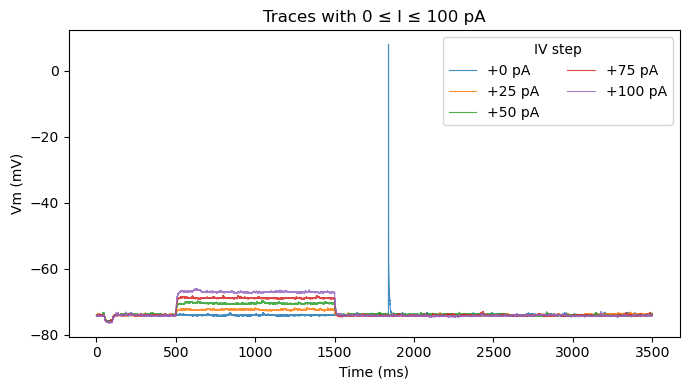

/tmp/ipykernel_2727935/2447863404.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


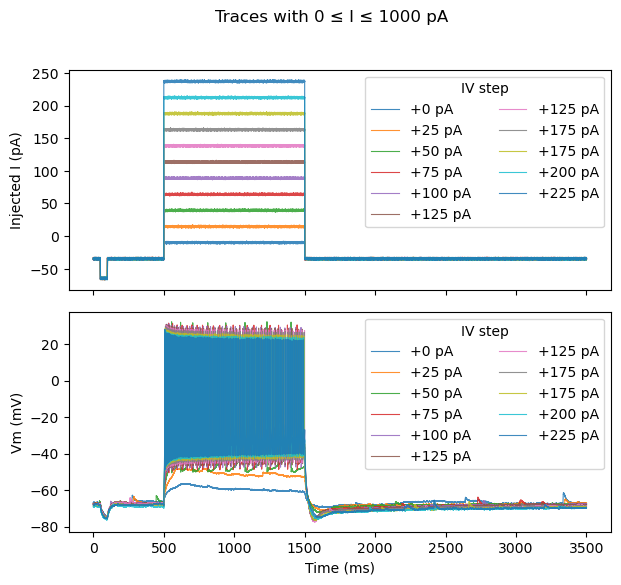

/tmp/ipykernel_2727935/2447863404.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


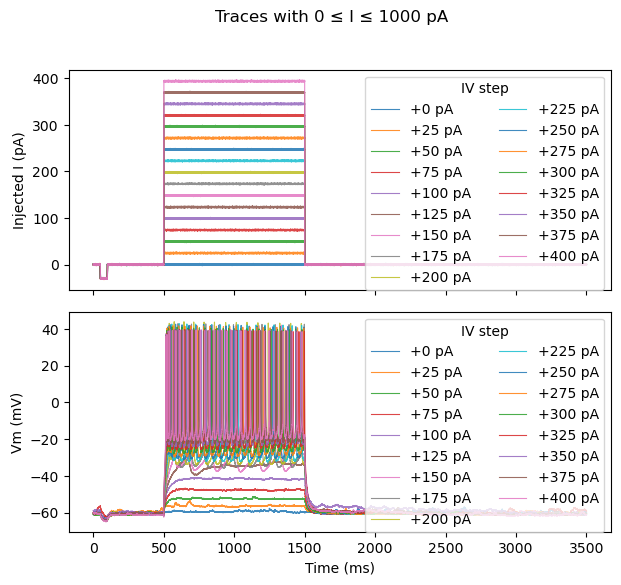

In [23]:
# Voltage only, +100 pA to +200 pA
plot_iv_sweeps("PV_example.mat", 0, 100, what="V")#,time_window=(450,1550),y_window=(-80,20))

# Current traces only, hyperpolarizing band −200 pA to −75 pA
plot_iv_sweeps("SST_example.mat", 0, 1000, what="both")

# Overlay voltage (solid) and current (dashed) for big depolarizing steps ≥+250 pA
plot_iv_sweeps("PyrExample.mat", 0, 1000, what="both")



Analysis

In [40]:
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter, find_peaks

# ---------------------------------------------------------------------
# CONFIGURATION  – tweak here, everything else picks up automatically
# ---------------------------------------------------------------------
FS            = 50_000        # Hz   (sampling rate)
SAVGOL_WIN    = 11            # smoothing window (samples), must be odd
SAVGOL_POLY   = 3             # polynomial order for Savitzky–Golay filter
DV_DT_THRESH  = 15.0          # mV / ms threshold for spike onset
MIN_V_PEAK    = -20.0         # mV  – ignore anything lower than this as a peak
HALF_REF      = 0.5           # where to measure half-width (0.5 = 50 % of amp)
REST_WIN_MS   = 5             # average this many ms at sweep start for Vrest
STEP_AT_MS    = 1000          # current sample used to label each sweep (ms)

# ---------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------
def smooth(v):
    return savgol_filter(v, SAVGOL_WIN, SAVGOL_POLY)

def dv_dt(v):
    # v in mV ; dt = 1/FS ⇒ multiply diff by FS and scale to ms
    return np.diff(v) * FS

# Constants (adjustable)
FS            = 50_000       # sampling rate (Hz)
MIN_PEAK_DIST_MS = 5        # minimum gap between successive peaks (ms)

def detect_spikes(v):
    """
    Return indices of AP peaks, with a minimum 5 ms refractory window.

    Criteria:
      1) dV/dt crosses DV_DT_THRESH,
      2) Local maximum ≥ MIN_V_PEAK,
      3) Enforce a minimum distance of MIN_PEAK_DIST_MS between peaks.
    """
    dv        = dv_dt(smooth(v))
    thr_cross = np.where(dv > DV_DT_THRESH)[0]
    if thr_cross.size == 0:
        return np.array([], dtype=int)

    min_dist_samples = int((MIN_PEAK_DIST_MS / 1000) * FS)
    peaks, _ = find_peaks(
        v,
        height=MIN_V_PEAK,
        distance=min_dist_samples
    )
    # keep only peaks that follow at least one threshold crossing
    valid = [p for p in peaks if np.any(thr_cross < p)]
    return np.array(valid, dtype=int)

def ap_metrics(v, peaks):
    """
    Calculate spike metrics for each peak index in `peaks`.
    Returns a list of dicts (one per spike).
    """
    metrics = []
    for pk in peaks:
        # ----- threshold = first time dv/dt > threshold within 2 ms before peak
        lookback = int(0.002 * FS)
        dv = dv_dt(smooth(v))
        thr_idx = pk - lookback + np.argmax(dv[pk - lookback: pk] > DV_DT_THRESH)
        Vthr = v[thr_idx]

        Vpk  = v[pk]
        amp  = Vpk - Vthr

        # ----- half-width
        half_level = Vthr + HALF_REF * amp
        # find left crossing
        left  = thr_idx + np.where(v[thr_idx:pk] >= half_level)[0][0]
        # find right crossing after peak
        right = pk + np.where(v[pk:]      <= half_level)[0][0]
        half_width_ms = (right - left) / FS * 1_000

        # ----- after-hyperpolarisation (AHP)
        # search 0–5 ms after peak for minimum
        ahp_window = v[pk : pk + int(0.005*FS)]
        if ahp_window.size > 0:
            Vmin = np.min(ahp_window)
            AHP_depth = Vthr - Vmin
            AHP_latency_ms = np.argmin(ahp_window) / FS * 1_000
        else:
            Vmin = np.nan
            AHP_depth = np.nan
            AHP_latency_ms = np.nan

        metrics.append(dict(
            V_thr_mV      = Vthr,
            V_peak_mV     = Vpk,
            amp_mV        = amp,
            half_width_ms = half_width_ms,
            AHP_min_mV    = Vmin,
            AHP_depth_mV  = AHP_depth,
            AHP_lat_ms    = AHP_latency_ms
        ))
    return metrics

# ---------------------------------------------------------------------
# MAIN ANALYSIS
# ---------------------------------------------------------------------
def analyse_cell(time_ms, I_traces, V_traces,
                 stim_period_ms=(500, 1500)):          # <-- here
    """
    Return sweep-level and spike-level DataFrames.

    stim_period_ms : tuple (start, end) in ms.
                     Only spikes whose peak time lies inside this window
                     are counted for firing-rate / FI curve metrics.
    """
    idx_step = int(STEP_AT_MS / 1000 * FS)
    step_pA  = [25 * round(I[idx_step] / 25) for I in I_traces]

    t_arr = np.asarray(time_ms)                        # for fast lookup
    sweep_recs, spike_recs = [], []

    stim_start_idx = np.searchsorted(t_arr, stim_period_ms[0])
    stim_end_idx   = np.searchsorted(t_arr, stim_period_ms[1])

    for sw, (I, V, step) in enumerate(zip(I_traces, V_traces, step_pA)):
        peaks = detect_spikes(V)

        # --------------- keep only peaks within stim window -------------
        peaks_in_window = [p for p in peaks
                           if stim_start_idx <= p < stim_end_idx]

        n_spk  = len(peaks_in_window)
        freq_hz = n_spk / ((stim_period_ms[1]-stim_period_ms[0]) / 1000)

        sweep_recs.append(dict(
            sweep    = sw,
            step_pA  = step,
            n_spikes = n_spk,
            freq_hz  = freq_hz
        ))

        for m in ap_metrics(V, peaks_in_window):
            spike_recs.append(dict(sweep=sw, step_pA=step, **m))

    return pd.DataFrame(sweep_recs), pd.DataFrame(spike_recs)


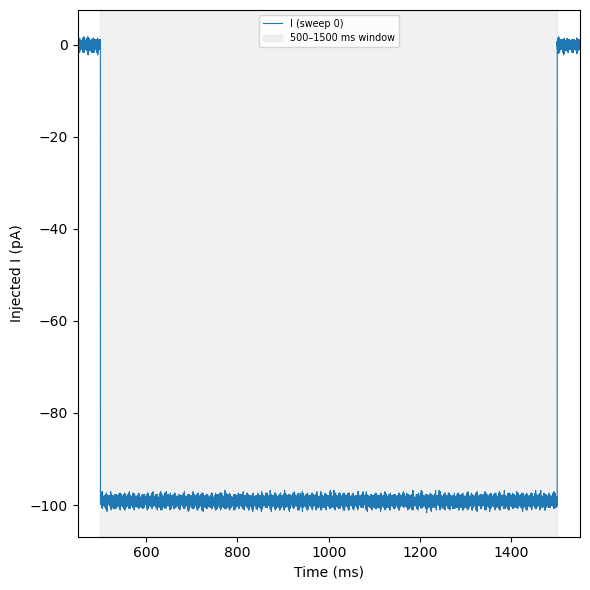

In [41]:
# 1. Load PyrExample
time_ms, I_traces, V_traces = load_currents_voltages("PyrExample.mat")

# 2. Peek at the first sweep’s I‐trace and the shaded 500–1500 ms region:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.plot(time_ms, I_traces[0], linewidth=0.8, label="I (sweep 0)")
plt.axvspan(500, 1500, color="lightgray", alpha=0.3, label="500–1500 ms window")
plt.xlim(450,1550)
plt.xlabel("Time (ms)")
plt.ylabel("Injected I (pA)")
plt.legend(fontsize="x-small")
plt.tight_layout()
plt.show()


In [43]:
sweep_df, spike_df = analyse_cell(
    time_ms, I_traces, V_traces,
    stim_period_ms=(500, 1500),  # unchanged if verified
)

# Diagnostic printout:
print("\n=== PyrExample: spikes per step_pA ===")
print(
    sweep_df.sort_values("step_pA")
    [["step_pA", "n_spikes", "freq_hz"]]
    .to_string(index=False)
)



=== PyrExample: spikes per step_pA ===
 step_pA  n_spikes  freq_hz
    -100         0      0.0
     -75         0      0.0
     -50         0      0.0
     -25         0      0.0
       0         0      0.0
      25         0      0.0
      50         0      0.0
      75         0      0.0
     100         0      0.0
     125         1      1.0
     150         6      6.0
     175        11     11.0
     200        14     14.0
     225        17     17.0
     250        20     20.0
     275        23     23.0
     300        28     28.0
     325        61     61.0
     350        89     89.0
     375       115    115.0
     400       169    169.0


In [29]:
cell_data = "PyrExample"

time_ms, I_tr, V_tr = load_currents_voltages(cell_data+".mat")

# default window 500-1500 ms
# sweep_df, spike_df = analyse_cell(time_ms, I_tr, V_tr)

# or custom: e.g. stim from 0.6 s to 1.4 s
sweep_df, spike_df = analyse_cell(time_ms, I_tr, V_tr,
                                  stim_period_ms=(400, 1600))

# ---- rheobase & FI curve with the corrected counts -------------
rheobase = sweep_df.loc[sweep_df.n_spikes>0, "step_pA"].min()
fi_df    = sweep_df.query("n_spikes>0")[["step_pA","freq_hz"]]\
                   .sort_values("step_pA")

print("Rheobase =", rheobase, "pA")
fi_df.plot.scatter(x="step_pA", y="freq_hz")    # quick FI plot




IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_AP_metrics(
        sweep_df, spike_df,
        *,
        # FI curve
        freq_hz=True,
        # AP metrics
        V_thr_mV=True, V_peak_mV=True, amp_mV=True,
        half_width_ms=True, AHP_min_mV=True,
        AHP_depth_mV=True, AHP_lat_ms=True,
        xlim=None,                    # tuple (xmin, xmax) in pA
        point_size=50,
        color="tab:blue",
        connect=False,
        fit=False,                    # draw least-squares fit
        figsize=(6, 2.2),
        marker="o",
        grid=True):
    """
    Make one subplot per selected metric vs injected current (step_pA).

    Parameters
    ----------
    sweep_df    : DataFrame with at least ["step_pA", "freq_hz"]  (FI curve source)
    spike_df    : DataFrame with spike metrics (output of analyse_cell)
    xlim        : (min, max) limits for X axis in pA  (None = auto)
    connect     : True to draw a line connecting the points
    fit         : True to draw least-squares linear fit
    Other style kwargs let you change colours, marker, etc.
    """
    # -- gather requested metrics -------------------------------------
    metric_flags = dict(
        # include FI curve
        freq_hz=freq_hz,
        # AP metrics
        V_thr_mV=V_thr_mV, V_peak_mV=V_peak_mV,
        amp_mV=amp_mV, half_width_ms=half_width_ms,
        AHP_min_mV=AHP_min_mV, AHP_depth_mV=AHP_depth_mV,
        AHP_lat_ms=AHP_lat_ms
    )
    selected = [m for m, flag in metric_flags.items() if flag]
    if not selected:
        raise ValueError("No metrics selected!")

    # -- build per-sweep averages for spike metrics -------------------
    spike_mean = spike_df.groupby("step_pA").mean(numeric_only=True)

    # ensure FI curve (freq_hz) is available
    sweep_metrics = sweep_df.set_index("step_pA")

    n_axes = len(selected)
    fig, axes = plt.subplots(
        n_axes, 1, sharex=True, figsize=(figsize[0], figsize[1] * n_axes),
        gridspec_kw=dict(hspace=0.2)
    )
    if n_axes == 1:
        axes = [axes]       # make iterable

    for ax, metric in zip(axes, selected):
        if metric == "freq_hz":
            y = sweep_df.set_index("step_pA")["freq_hz"]
        else:
            y = spike_mean[metric]

        x = y.index.values      # step_pA acts as index

        # scatter
        ax.scatter(x, y, s=point_size, color=color, marker=marker, zorder=3)

        # connect points
        if connect and len(x) > 1:
            ax.plot(x, y, color=color, linewidth=1)

        # fit line
        if fit and len(x) > 1:
            m, b = np.polyfit(x, y, 1)
            ax.plot(x, m * x + b,
                    color=color, linestyle="--", linewidth=1,
                    label=f"fit: y={m:.3g}·x+{b:.3g}")
            ax.legend(loc="best", fontsize="x-small")

        ax.set_ylabel(metric.replace("_", "\n"), fontsize=9)
        if grid:
            ax.grid(True, linewidth=0.3, alpha=0.6)

    axes[-1].set_xlabel("Injected current (pA)")
    if xlim:
        axes[-1].set_xlim(*xlim)

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2511333/2836359163.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


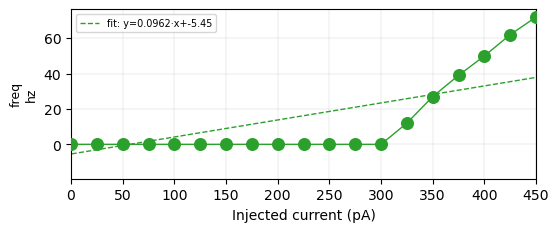

/tmp/ipykernel_2511333/2836359163.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


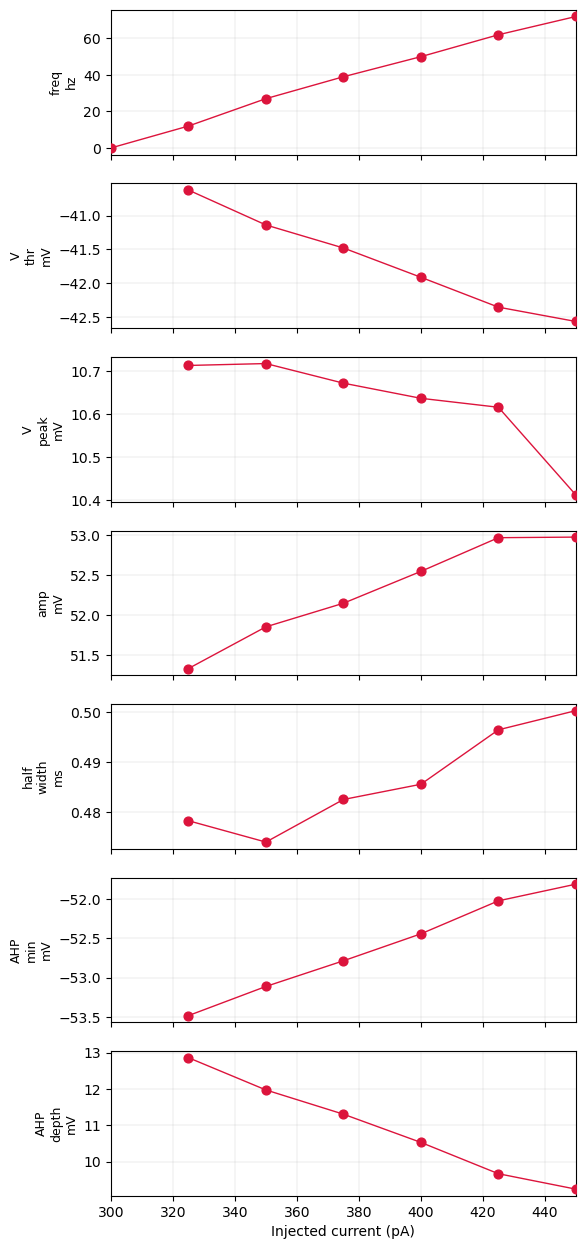

/tmp/ipykernel_2511333/2836359163.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


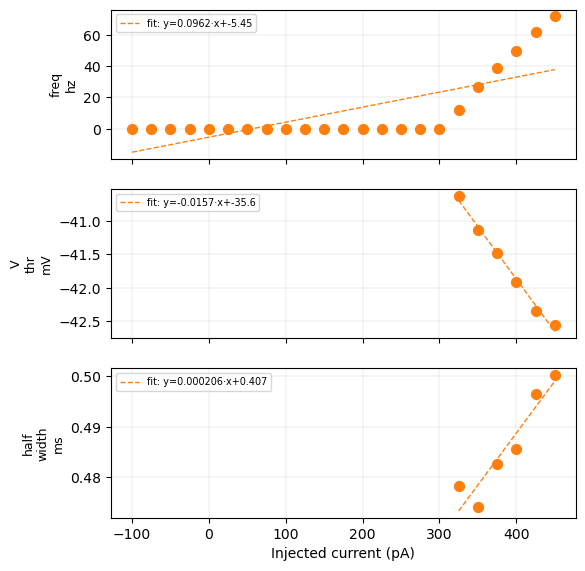

In [ ]:
cell_data = "PyrExample"

time_ms, I_tr, V_tr = load_currents_voltages(cell_data+".mat")

# FI curve only, with line & fit, x-axis 0-300 pA
plot_AP_metrics(
    sweep_df, spike_df,
    V_thr_mV=False, V_peak_mV=False, amp_mV=False,
    half_width_ms=False, AHP_min_mV=False,
    AHP_depth_mV=False, AHP_lat_ms=False,
    xlim=(0, 450), connect=True, fit=True, point_size=70, color="tab:green"
)

# Everything except AHP timing, no fit, red symbols, 25-pA grid visible
plot_AP_metrics(
    sweep_df, spike_df,
    AHP_lat_ms=False,
    color="crimson", point_size=40, connect=True,
    xlim=(300, 450)
)

# Minimal: threshold & half-width only
plot_AP_metrics(
    sweep_df, spike_df,
    V_thr_mV=True, half_width_ms=True,
    V_peak_mV=False, amp_mV=False, AHP_min_mV=False,
    AHP_depth_mV=False, AHP_lat_ms=False,
    fit=True, color="tab:orange"
)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_AP_metrics(
        sweep_df, spike_df,
        *,
        # FI curve (on/off)
        freq_hz=True,
        # AP metrics
        V_thr_mV=True, V_peak_mV=True, amp_mV=True,
        half_width_ms=True, AHP_min_mV=True,
        AHP_depth_mV=True, AHP_lat_ms=True,
        # common styling
        xlim=None,                    # tuple (xmin, xmax) in pA
        point_size=50,
        color="tab:blue",
        connect=False,
        fit=False,                    # draw least-squares fit
        figsize=(6, 2.2),
        marker="o",
        grid=True
    ):
    """
    Make one subplot per selected metric vs injected current (step_pA),
    plus FI‐curve slope & rheobase printing.

    Parameters
    ----------
    sweep_df : DataFrame with columns ["step_pA", "freq_hz", ...]
    spike_df : DataFrame with columns ["step_pA", "V_thr_mV", "V_peak_mV", ...]
    freq_hz  : bool, include the FI curve (n_spikes / stim_duration)
    V_thr_mV, V_peak_mV, amp_mV, half_width_ms, AHP_min_mV,
    AHP_depth_mV, AHP_lat_ms : bool, toggle each AP metric on/off
    xlim     : (xmin, xmax) in pA for the x‐axis
    point_size : scatter‐plot marker size
    color    : color for all scatters & fits
    connect  : bool, draw a line connecting the points
    fit      : bool, perform & draw a least‐squares fit; prints slope for FI
    figsize  : height & width per subplot (height will be “n_axes × figsize[1]”)
    marker   : matplotlib marker style (e.g. "o", "s", ...)
    grid     : bool, draw grid‐lines in each axis
    """

    # --- 1. Gather all requested metrics into a dict of flags ------------
    metric_flags = dict(
        freq_hz=freq_hz,
        V_thr_mV=V_thr_mV, V_peak_mV=V_peak_mV, amp_mV=amp_mV,
        half_width_ms=half_width_ms, AHP_min_mV=AHP_min_mV,
        AHP_depth_mV=AHP_depth_mV, AHP_lat_ms=AHP_lat_ms
    )

    selected = [m for m, on in metric_flags.items() if on]
    if not selected:
        raise ValueError("No metrics selected!  Turn on at least one flag.")

    # --- 2. Compute rheobase and optionally print it ----------------------
    # Rheobase = smallest step_pA with freq_hz > 0
    if "freq_hz" in selected:
        nonzero = sweep_df.loc[sweep_df["freq_hz"] > 0, "step_pA"]
        if len(nonzero) > 0:
            rheobase = nonzero.min()
            print(f"→ Rheobase = {rheobase} pA")
        else:
            print("→ Rheobase: no spikes detected at any step.")

    # --- 3. Build per‐sweep averages for spike metrics --------------------
    # Group spike_df by step_pA and take the mean of each selected AP metric
    spike_mean = spike_df.groupby("step_pA").mean(numeric_only=True)

    # Use sweep_df indexed by step_pA for freq_hz
    sweep_metrics = sweep_df.set_index("step_pA")

    # --- 4. Create subplots, one per metric -------------------------------
    n_axes = len(selected)
    fig, axes = plt.subplots(
        n_axes, 1,
        sharex=True,
        figsize=(figsize[0], figsize[1] * n_axes),
        gridspec_kw=dict(hspace=0.2)
    )
    if n_axes == 1:
        axes = [axes]  # make it iterable

    # --- 5. Loop through each metric and plot -----------------------------
    for ax, metric in zip(axes, selected):
        # 5a. Get x & y data
        if metric == "freq_hz":
            # FI: x = step_pA index, y = freq_hz
            y_all = sweep_metrics["freq_hz"].dropna()
            x_all = y_all.index.values
            # When fitting FI, only use points with freq_hz > 0
            if fit:
                mask_fit = y_all.values > 0
                x = x_all[mask_fit]
                y = y_all.values[mask_fit]
            else:
                x = x_all
                y = y_all.values
        else:
            # AP metric: x = step_pA index, y = mean(metric) from spike_mean
            if metric not in spike_mean.columns:
                # In case a column is missing (no spikes), skip blank plot
                x = np.array([])
                y = np.array([])
            else:
                y_all = spike_mean[metric].dropna()
                x = y_all.index.values
                y = y_all.values

        # 5b. Scatter‐plot the points
        if x.size and y.size:
            ax.scatter(x, y,
                       s=point_size,
                       color=color,
                       marker=marker,
                       zorder=3)

            # 5c. Optionally connect the dots with a line
            if connect and x.size > 1:
                ax.plot(x, y, color=color, linewidth=1)

            # 5d. Optionally fit a least‐squares line
            if fit and x.size > 1:
                # Special: for freq_hz, our x & y already exclude y=0
                m, b = np.polyfit(x, y, 1)
                ax.plot(x, m * x + b,
                        color=color, linestyle="--", linewidth=1,
                        label=f"slope={m:.3f}")
                # If this is the FI metric, print the slope
                if metric == "freq_hz":
                    print(f"→ FI slope = {m:.3f} Hz/pA")
                ax.legend(loc="best", fontsize="x-small")
        else:
            # No data to plot (e.g. metric not present)
            ax.text(0.5, 0.5, "no data", ha="center", va="center", color="gray")
            ax.set_ylim(0, 1)  # just show something

        # 5e. Label each subplot
        ax.set_ylabel(metric.replace("_", "\n"), fontsize=9)
        if grid:
            ax.grid(True, linewidth=0.3, alpha=0.6)

    # --- 6. Final touches on X‐axis ---------------------------------------
    axes[-1].set_xlabel("Injected current (pA)")
    if xlim:
        axes[-1].set_xlim(*xlim)

    # plt.tight_layout()
    plt.show()


→ Rheobase = 325 pA
→ FI slope = 0.475 Hz/pA


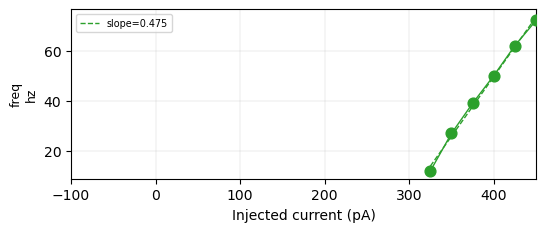

→ Rheobase = 325 pA
→ FI slope = 0.475 Hz/pA


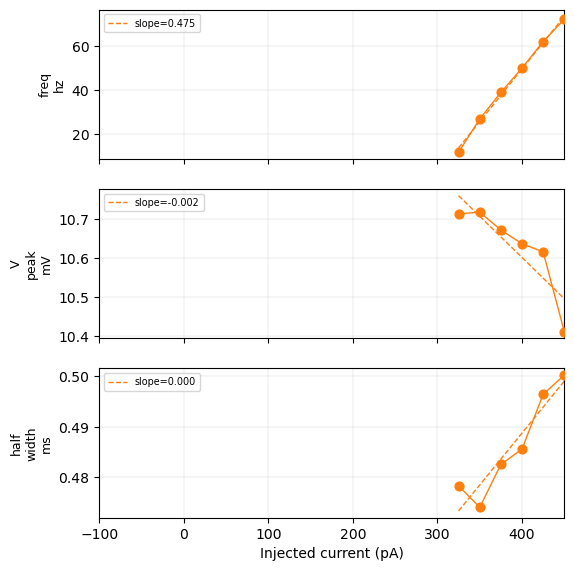

In [ ]:
plot_AP_metrics(
    sweep_df, spike_df,
    freq_hz=True,
    V_thr_mV=False, V_peak_mV=False, amp_mV=False,
    half_width_ms=False, AHP_min_mV=False,
    AHP_depth_mV=False, AHP_lat_ms=False,
    xlim=(-100, 450),
    connect=True, fit=True,
    point_size=60, color="tab:green"
)

plot_AP_metrics(
    sweep_df, spike_df,
    freq_hz=True,
    V_thr_mV=False, V_peak_mV=True, amp_mV=False,
    half_width_ms=True, AHP_min_mV=False,
    AHP_depth_mV=False, AHP_lat_ms=False,
    xlim=(-100, 450),
    connect=True, fit=True,
    point_size=40, color="tab:orange"
)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_AP_metrics(
        sweep_df, spike_df,
        *,
        # FI curve (on/off)
        freq_hz=True,
        # AP metrics
        V_thr_mV=True, V_peak_mV=True, amp_mV=True,
        half_width_ms=True, AHP_min_mV=True,
        AHP_depth_mV=True, AHP_lat_ms=True,
        # Common styling
        xlim=None,                    # tuple (xmin, xmax) in pA
        point_size=50,
        color="tab:blue",
        connect=False,
        fit=False,                    # draw least-squares fit
        figsize=(6, 2.2),
        marker="o",
        grid=True
    ):
    """
    Make one subplot per selected metric vs injected current (step_pA),
    plus FI‐curve slope & rheobase printing.

    - Zero‐frequency points are plotted, but NOT used in the fit.
    - The full fit equation is shown in the legend; only the slope prints.

    Parameters
    ----------
    sweep_df : DataFrame with columns ["step_pA", "freq_hz", ...]
    spike_df : DataFrame with columns ["step_pA", "V_thr_mV", "V_peak_mV", ...]
    freq_hz  : bool, include the FI curve (n_spikes / stim_duration)
    V_thr_mV, V_peak_mV, amp_mV, half_width_ms, AHP_min_mV,
    AHP_depth_mV, AHP_lat_ms : bool, toggle each AP metric on/off
    xlim     : (xmin, xmax) in pA for the x‐axis
    point_size : scatter‐plot marker size
    color    : color for all scatters & fits
    connect  : bool, draw a line connecting the points
    fit      : bool, perform & draw a least‐squares fit; prints slope for FI
    figsize  : height & width per subplot (height = “n_axes × figsize[1]”)
    marker   : matplotlib marker style (e.g. "o", "s", ...)
    grid     : bool, draw grid‐lines in each axis
    """

    # --- 1. Gather all requested metrics into a dict of flags ------------
    metric_flags = dict(
        freq_hz=freq_hz,
        V_thr_mV=V_thr_mV, V_peak_mV=V_peak_mV, amp_mV=amp_mV,
        half_width_ms=half_width_ms, AHP_min_mV=AHP_min_mV,
        AHP_depth_mV=AHP_depth_mV, AHP_lat_ms=AHP_lat_ms
    )

    selected = [m for m, on in metric_flags.items() if on]
    if not selected:
        raise ValueError("No metrics selected!  Turn on at least one flag.")

    # --- 2. Compute rheobase and print it if FI is in “selected” --------------
    if "freq_hz" in selected:
        nonzero = sweep_df.loc[sweep_df["freq_hz"] > 0, "step_pA"]
        if len(nonzero) > 0:
            rheobase = nonzero.min()
            print(f"→ Rheobase = {rheobase} pA")
        else:
            print("→ Rheobase: no spikes detected at any step.")

    # --- 3. Build per‐sweep averages for spike metrics ----------------------
    spike_mean = spike_df.groupby("step_pA").mean(numeric_only=True)
    sweep_metrics = sweep_df.set_index("step_pA")

    # --- 4. Create subplots, one per metric --------------------------------
    n_axes = len(selected)
    fig, axes = plt.subplots(
        n_axes, 1,
        sharex=True,
        figsize=(figsize[0], figsize[1] * n_axes),
        gridspec_kw=dict(hspace=0.2)
    )
    if n_axes == 1:
        axes = [axes]  # make iterable

    # --- 5. Loop through each metric and plot -------------------------------
    for ax, metric in zip(axes, selected):
        if metric == "freq_hz":
            # FI: plot all points, but fit only nonzero
            y_all = sweep_metrics["freq_hz"].dropna()
            x_all = y_all.index.values

            # Plot zero AND nonzero points
            ax.scatter(x_all, y_all.values,
                       s=point_size, color=color, marker=marker, zorder=3)

            # Optionally connect ALL points
            if connect and x_all.size > 1:
                ax.plot(x_all, y_all.values, color=color, linewidth=1)

            # Fit ONLY on freq > 0
            if fit:
                mask_fit = y_all.values > 0
                x_fit = x_all[mask_fit]
                y_fit = y_all.values[mask_fit]
                if x_fit.size > 1:
                    m, b = np.polyfit(x_fit, y_fit, 1)
                    # Draw the fit line across the full plotted x-range
                    x_line = np.array([x_fit.min(), x_fit.max()])
                    y_line = m * x_line + b
                    ax.plot(x_line, y_line,
                            color=color, linestyle="--", linewidth=1,
                            label=f"y = {m:.3f}·x + {b:.3f}")
                    print(f"→ FI slope = {m:.3f} Hz/pA")
                    ax.legend(loc="best", fontsize="x-small")
        else:
            # AP metric: use all available sweeps that have a mean in spike_mean
            if metric in spike_mean.columns:
                y_all = spike_mean[metric].dropna()
                x_all = y_all.index.values

                ax.scatter(x_all, y_all.values,
                           s=point_size, color=color, marker=marker, zorder=3)

                if connect and x_all.size > 1:
                    ax.plot(x_all, y_all.values, color=color, linewidth=1)

                if fit and x_all.size > 1:
                    m, b = np.polyfit(x_all, y_all.values, 1)
                    x_line = np.array([x_all.min(), x_all.max()])
                    y_line = m * x_line + b
                    ax.plot(x_line, y_line,
                            color=color, linestyle="--", linewidth=1,
                            label=f"y = {m:.3f}·x + {b:.3f}")
                    ax.legend(loc="best", fontsize="x-small")
            else:
                # No data for that metric
                ax.text(0.5, 0.5, "no data", ha="center", va="center", color="gray")
                ax.set_ylim(0, 1)

        # Label each subplot
        ax.set_ylabel(metric.replace("_", "\n"), fontsize=9)
        if grid:
            ax.grid(True, linewidth=0.3, alpha=0.6)

    # --- 6. Final touches on X‐axis -----------------------------------------
    axes[-1].set_xlabel("Injected current (pA)")
    if xlim:
        axes[-1].set_xlim(*xlim)

    # plt.tight_layout()
    plt.show()


→ Rheobase = 325 pA
→ FI slope = 0.475 Hz/pA


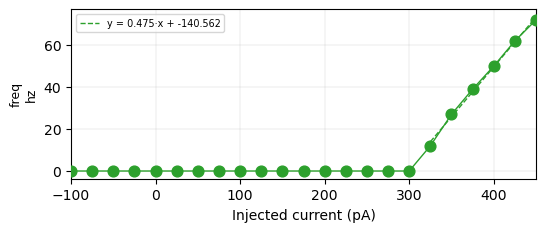

→ Rheobase = 325 pA
→ FI slope = 0.475 Hz/pA


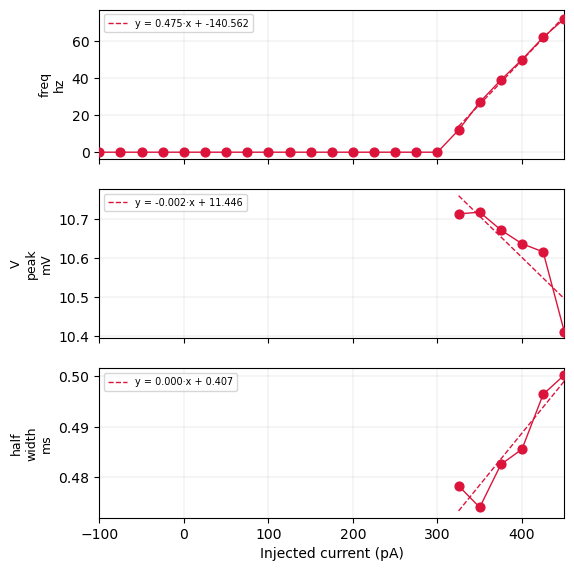

In [ ]:
plot_AP_metrics(
    sweep_df, spike_df,
    freq_hz=True,
    V_thr_mV=False, V_peak_mV=False, amp_mV=False,
    half_width_ms=False, AHP_min_mV=False,
    AHP_depth_mV=False, AHP_lat_ms=False,
    xlim=(-100, 450),
    connect=True, fit=True,
    point_size=60, color="tab:green"
)

plot_AP_metrics(
    sweep_df, spike_df,
    freq_hz=True, V_peak_mV=True, half_width_ms=True,
    V_thr_mV=False, amp_mV=False,
    AHP_min_mV=False, AHP_depth_mV=False, AHP_lat_ms=False,
    xlim=(-100, 450),
    connect=True, fit=True,
    point_size=40, color="crimson"
)

In [ ]:
time_ms, I_tr, V_tr = load_currents_voltages("PyrExample.mat")
sweep_df, spike_df = analyse_cell(time_ms, I_tr, V_tr, stim_period_ms=(500, 1500))

# Diagnostic printout:
print("\n=== PyrExample: spikes per step_pA ===")
print(sweep_df.sort_values("step_pA")[["step_pA", "n_spikes", "freq_hz"]].to_string(index=False))


In [ ]:
# Quick plot of the current trace for sweep #0, to see where the step lives:
import matplotlib.pyplot as plt

# Just inspect the very first sweep’s current:
plt.figure(figsize=(4,2))
plt.plot(time_ms, I_tr[0], linewidth=0.8)
plt.xlabel("Time (ms)")
plt.ylabel("I (pA)")
plt.title("PyrExample – Sweep 0 current (pA)")
plt.axvspan(500, 1500, color="gray", alpha=0.2, label="500–1500 ms window")
plt.legend(fontsize="x-small")
plt.tight_layout()
plt.show()


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

# ------------------------ CONSTANTS ------------------------
FS               = 50_000       # Hz
SAVGOL_WIN       = 11           # must be odd
SAVGOL_POLY      = 3
DV_DT_THRESH     = 15.0         # mV/ms (change to 20 if still too sensitive)
MIN_V_PEAK       = -0.0         # mV (change to 0.0 to ignore sub‐threshold humps)
MIN_PEAK_DIST_MS = 5            # 5 ms refractory
HALF_REF         = 0.5
STEP_AT_MS       = 1000         # to label injected step
# -----------------------------------------------------------

def smooth(v):
    return savgol_filter(v, SAVGOL_WIN, SAVGOL_POLY)

def dv_dt(v):
    # dv/dt in mV/ms (diff * FS)
    return np.diff(v) * FS

def detect_spikes(v):
    """
    Return indices of AP peaks, enforcing a 5 ms refractory window.
    """
    dv = dv_dt(smooth(v))
    thr_cross = np.where(dv > DV_DT_THRESH)[0]
    if thr_cross.size == 0:
        return np.array([], dtype=int)

    min_dist_samples = int((MIN_PEAK_DIST_MS / 1000) * FS)
    peaks, props = find_peaks(
        v,
        height=MIN_V_PEAK,
        distance=min_dist_samples
    )
    valid = [p for p in peaks if np.any(thr_cross < p)]
    return np.array(valid, dtype=int)

def ap_metrics(v, peaks):
    """
    Calculate AP metrics for each peak index in `peaks`.
    Returns a list of dicts; missing half‐widths → NaN.
    """
    metrics = []
    for pk in peaks:
        lookback = int(0.002 * FS)
        dv = dv_dt(smooth(v))
        window_start = max(pk - lookback, 0)
        cand = np.where(dv[window_start:pk] > DV_DT_THRESH)[0]
        if cand.size:
            thr_idx = window_start + cand[0]
            Vthr = v[thr_idx]
        else:
            continue  # skip if no clear threshold found

        Vpk = v[pk]
        amp = Vpk - Vthr
        half_level = Vthr + HALF_REF * amp

        # Find half‐width left crossing
        left_cand = np.where(v[thr_idx:pk] >= half_level)[0]
        left = (thr_idx + left_cand[0]) if left_cand.size else None

        # Find half‐width right crossing
        right_cand = np.where(v[pk:] <= half_level)[0]
        right = (pk + right_cand[0]) if right_cand.size else None

        if left is not None and right is not None and right > left:
            half_width_ms = (right - left) / FS * 1000
        else:
            half_width_ms = np.nan

        ahp_window = v[pk : pk + int(0.005 * FS)]
        if ahp_window.size:
            Vmin = np.min(ahp_window)
            AHP_depth = Vthr - Vmin
            AHP_latency_ms = np.argmin(ahp_window) / FS * 1000
        else:
            Vmin = np.nan
            AHP_depth = np.nan
            AHP_latency_ms = np.nan

        metrics.append(dict(
            V_thr_mV      = Vthr,
            V_peak_mV     = Vpk,
            amp_mV        = amp,
            half_width_ms = half_width_ms,
            AHP_min_mV    = Vmin,
            AHP_depth_mV  = AHP_depth,
            AHP_lat_ms    = AHP_latency_ms
        ))
    return metrics

def analyse_cell(time_ms, I_traces, V_traces,
                 stim_period_ms=(500, 1500),
                 auto_detect=False, rel_thresh=0.7):
    """
    Return (sweep_df, spike_df).
    If auto_detect=True, ignore stim_period_ms and detect plateau window in sweep 0.
    """
    # 1) Detect plateau window if requested
    if auto_detect:
        I0 = I_traces[0]
        idx_plateau = np.where(np.abs(I0) >= rel_thresh * np.max(np.abs(I0)))[0]
        if idx_plateau.size == 0:
            raise RuntimeError("No plateau found in sweep 0 for auto_detect!")
        stim_start_idx = idx_plateau.min()
        stim_end_idx   = idx_plateau.max()
        stim_start_ms  = stim_start_idx / FS * 1000
        stim_end_ms    = stim_end_idx / FS * 1000
        print(f"→ Auto‐detected plateau window: ({stim_start_ms:.1f}, {stim_end_ms:.1f}) ms")
    else:
        stim_start_ms, stim_end_ms = stim_period_ms
        stim_start_idx = np.searchsorted(time_ms, stim_start_ms)
        stim_end_idx   = np.searchsorted(time_ms, stim_end_ms)

    # 2) Label each sweep by its injected‐step at t=1000 ms
    idx_step = int(STEP_AT_MS / 1000 * FS)
    step_pA_list = [25 * round(I[idx_step] / 25) for I in I_traces]

    sweep_records = []
    spike_records = []

    # 3) Loop over sweeps
    for sw, (I, V, step_pA) in enumerate(zip(I_traces, V_traces, step_pA_list)):
        all_peaks = detect_spikes(V)
        # Keep only peaks inside [stim_start_idx, stim_end_idx)
        peaks_in_win = [p for p in all_peaks if stim_start_idx <= p < stim_end_idx]

        n_spikes = len(peaks_in_win)
        stim_dur_s = (stim_end_ms - stim_start_ms) / 1000
        freq_hz = n_spikes / stim_dur_s if stim_dur_s > 0 else 0.0

        sweep_records.append(dict(
            sweep    = sw,
            step_pA  = step_pA,
            n_spikes = n_spikes,
            freq_hz  = freq_hz
        ))

        for pk in peaks_in_win:
            for m in ap_metrics(V, [pk]):
                spike_records.append(dict(
                    sweep   = sw,
                    step_pA = step_pA,
                    **m
                ))

    sweep_df = pd.DataFrame(sweep_records)
    spike_df = pd.DataFrame(spike_records)
    return sweep_df, spike_df

def plot_AP_metrics(
        sweep_df, spike_df,
        *,
        freq_hz=True,
        V_thr_mV=True, V_peak_mV=True, amp_mV=True,
        half_width_ms=True, AHP_min_mV=True,
        AHP_depth_mV=True, AHP_lat_ms=True,
        xlim=None,
        point_size=50,
        color="tab:blue",
        connect=False,
        fit=False,
        figsize=(6, 2.2),
        marker="o",
        grid=True
    ):
    """
    Plot each selected metric vs injected current (“step_pA”). 
    FI is plotted with zero‐freq points included, but fit only on freq>0.
    """
    metric_flags = dict(
        freq_hz=freq_hz,
        V_thr_mV=V_thr_mV, V_peak_mV=V_peak_mV, amp_mV=amp_mV,
        half_width_ms=half_width_ms, AHP_min_mV=AHP_min_mV,
        AHP_depth_mV=AHP_depth_mV, AHP_lat_ms=AHP_lat_ms
    )

    selected = [m for m, on in metric_flags.items() if on]
    if not selected:
        raise ValueError("No metrics selected!  Turn on at least one flag.")

    # Rheobase
    if "freq_hz" in selected:
        nonzero = sweep_df.loc[sweep_df["freq_hz"] > 0, "step_pA"]
        if len(nonzero):
            print(f"→ Rheobase = {nonzero.min():.0f} pA")
        else:
            print("→ Rheobase: no spikes detected.")

    spike_mean = spike_df.groupby("step_pA").mean(numeric_only=True)
    sweep_metrics = sweep_df.set_index("step_pA")

    n_axes = len(selected)
    fig, axes = plt.subplots(
        n_axes, 1, sharex=True,
        figsize=(figsize[0], figsize[1] * n_axes),
        gridspec_kw=dict(hspace=0.2)
    )
    if n_axes == 1:
        axes = [axes]

    for ax, metric in zip(axes, selected):
        if metric == "freq_hz":
            y_all = sweep_metrics["freq_hz"].dropna()
            x_all = y_all.index.values
            ax.scatter(x_all, y_all.values,
                       s=point_size, c=color, marker=marker, zorder=3)
            if connect and x_all.size > 1:
                ax.plot(x_all, y_all.values, color=color, linewidth=1)
            if fit:
                mask_fit = y_all.values > 0
                x_fit = x_all[mask_fit]
                y_fit = y_all.values[mask_fit]
                if x_fit.size > 1:
                    m, b = np.polyfit(x_fit, y_fit, 1)
                    # draw line across x_fit range
                    x_line = np.array([x_fit.min(), x_fit.max()])
                    y_line = m * x_line + b
                    ax.plot(x_line, y_line,
                            color=color, ls="--", lw=1,
                            label=f"y = {m:.3f}·x + {b:.3f}")
                    print(f"→ FI slope = {m:.3f} Hz/pA")
                    ax.legend(loc="best", fontsize="x-small")
        else:
            if metric in spike_mean.columns:
                y_all = spike_mean[metric].dropna()
                x_all = y_all.index.values
                ax.scatter(x_all, y_all.values,
                           s=point_size, c=color, marker=marker, zorder=3)
                if connect and x_all.size > 1:
                    ax.plot(x_all, y_all.values, color=color, linewidth=1)
                if fit and x_all.size > 1:
                    m, b = np.polyfit(x_all, y_all.values, 1)
                    x_line = np.array([x_all.min(), x_all.max()])
                    y_line = m * x_line + b
                    ax.plot(x_line, y_line,
                            color=color, ls="--", lw=1,
                            label=f"y = {m:.3f}·x + {b:.3f}")
                    ax.legend(loc="best", fontsize="x-small")
            else:
                ax.text(0.5, 0.5, "no data", ha="center", va="center", color="gray")
                ax.set_ylim(0, 1)

        ax.set_ylabel(metric.replace("_", "\n"), fontsize=9)
        if grid:
            ax.grid(True, linewidth=0.3, alpha=0.6)

    axes[-1].set_xlabel("Injected current (pA)")
    if xlim:
        axes[-1].set_xlim(*xlim)

    # plt.tight_layout()
    plt.show()


In [45]:
time_ms, I_tr, V_tr = load_currents_voltages("SST_example.mat")

# If you know 500–1500 ms is correct:
sweep_df, spike_df = analyse_cell(
    time_ms, I_tr, V_tr,
    stim_period_ms=(500, 1500),
    auto_detect=False
)

# Or let the code find the plateau for you:
sweep_df, spike_df = analyse_cell(
    time_ms, I_tr, V_tr,
    stim_period_ms=None,
    auto_detect=True
)


→ Auto‐detected plateau window: (500.0, 1500.0) ms


→ Rheobase = 125 pA
→ FI slope = 0.113 Hz/pA


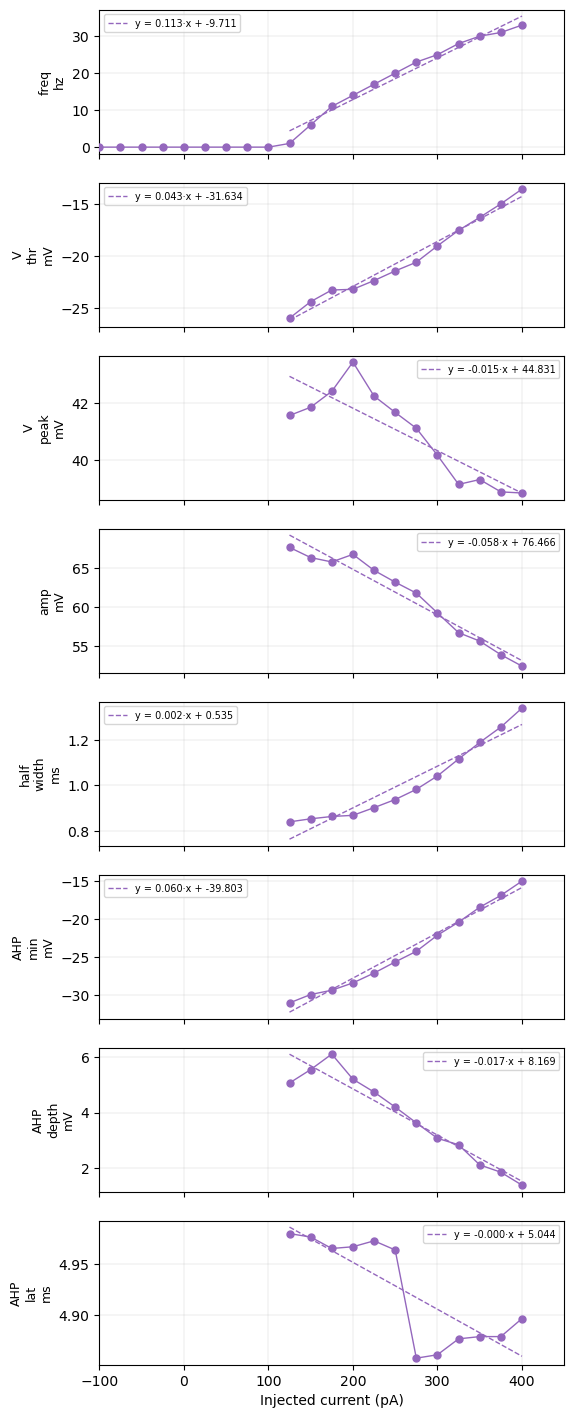

In [50]:
plot_AP_metrics(
    sweep_df, spike_df,
    freq_hz=True,
    V_thr_mV=True, V_peak_mV=True, amp_mV=True,
    half_width_ms=True, AHP_min_mV=True,
    AHP_depth_mV=True, AHP_lat_ms=True,
    xlim=(-100, 450),
    connect=True, fit=True,
    point_size=25, color="tab:purple"
)


In [84]:
# ============================================================
#  Electrophysiology “IV-family” Analysis Pipeline
#  ------------------------------------------------------------
#  • Loads .mat files that contain paired I & V sweeps
#  • Detects spikes, extracts sweep- and spike-level metrics
#  • Plots one or many metrics across any number of datasets
#  ------------------------------------------------------------
#  Paste this entire cell into a Jupyter notebook and run once.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import scipy.io as sio

# ------------------------------------------------------------------
# 0️⃣  GLOBAL CONFIGURATION  (edit these to suit your rig)
# ------------------------------------------------------------------
FS               = 50_000      # <— sampling rate [Hz]
SAVGOL_WIN       = 11          # Savitzky–Golay window (odd samples)
SAVGOL_POLY      = 3           # SG polynomial order
DV_DT_THRESH     = 15.0        # dV/dt threshold [mV/ms] for spike onset
MIN_V_PEAK       = 0.0         # minimum peak amplitude [mV] (ignore bumps < 0 mV)
MIN_PEAK_DIST_MS = 5           # refractory: min distance between spikes [ms]
HALF_REF         = 0.5         # half-width reference (0.5 = 50 % amplitude)
STEP_AT_MS       = 1000        # time-point used to label injected current [ms]

# A colour per dataset key (extend as needed)
COLORS = {"PN": "red",
          "PV": "blue",
          "SST": "magenta",
          "__default__": "black"}

POINT_SIZE = 25    # scatter size for plots
CONNECT     = True # connect successive points with a line

# ------------------------------------------------------------------
# 1️⃣  LOW-LEVEL SIGNAL HELPERS
# ------------------------------------------------------------------
def smooth(v: np.ndarray) -> np.ndarray:
    """Savitzky–Golay smoothing (mild, preserves spike amplitudes)."""
    return savgol_filter(v, SAVGOL_WIN, SAVGOL_POLY)

def dv_dt(v: np.ndarray) -> np.ndarray:
    """dV/dt in mV/ms (first difference × fs)."""
    return np.diff(v) * FS

# ------------------------------------------------------------------
# 2️⃣  SPIKE DETECTION
# ------------------------------------------------------------------
def detect_spikes(v: np.ndarray) -> np.ndarray:
    """
    Return indices of spike peaks.

    1. Smooth the trace slightly.
    2. Find all points where dV/dt > DV_DT_THRESH.
    3. Apply `scipy.signal.find_peaks` with:
          • min peak height = MIN_V_PEAK
          • min peak distance = MIN_PEAK_DIST_MS
    4. Keep only peaks that follow at least one threshold crossing.
    """
    dv = dv_dt(smooth(v))
    thr_cross = np.where(dv > DV_DT_THRESH)[0]
    if thr_cross.size == 0:
        return np.array([], dtype=int)

    min_dist = int(MIN_PEAK_DIST_MS / 1000 * FS)
    peaks, _ = find_peaks(v,
                          height=MIN_V_PEAK,
                          distance=min_dist)
    valid = [p for p in peaks if np.any(thr_cross < p)]
    return np.array(valid, dtype=int)

# ------------------------------------------------------------------
# 3️⃣  PER-SPIKE AP METRICS
# ------------------------------------------------------------------
def ap_metrics(v: np.ndarray, peaks: list[int]) -> list[dict]:
    """
    Calculate classic AP shape metrics for every peak index in `peaks`.

    Missing measurements (e.g. half-width when crossings cannot be found)
    are returned as NaN to avoid crashing downstream code.
    """
    out = []
    for pk in peaks:
        # —— threshold (first dV/dt > threshold within 2 ms pre-peak)
        lookback = int(0.002 * FS)
        dv = dv_dt(smooth(v))
        win0 = max(pk - lookback, 0)
        idx = np.where(dv[win0:pk] > DV_DT_THRESH)[0]
        if idx.size == 0:
            # cannot define threshold → skip this spike
            continue
        thr_idx = win0 + idx[0]
        Vthr = v[thr_idx]

        Vpk  = v[pk]
        amp  = Vpk - Vthr

        # —— half-width
        half_level = Vthr + HALF_REF * amp
        left  = np.where(v[thr_idx:pk] >= half_level)[0]
        right = np.where(v[pk:]       <= half_level)[0]
        if left.size and right.size:
            hw_ms = ( (thr_idx + left[0]) - (pk + right[0]) ) / FS * -1000
        else:
            hw_ms = np.nan

        # —— AHP (0–5 ms post-peak)
        ahp_seg = v[pk : pk + int(0.005*FS)]
        if ahp_seg.size:
            Vmin = ahp_seg.min()
            AHP_depth = Vthr - Vmin
            AHP_lat   = ahp_seg.argmin() / FS * 1000
        else:
            Vmin = AHP_depth = AHP_lat = np.nan

        out.append(dict(
            V_thr_mV      = Vthr,
            V_peak_mV     = Vpk,
            amp_mV        = amp,
            half_width_ms = hw_ms,
            AHP_min_mV    = Vmin,
            AHP_depth_mV  = AHP_depth,
            AHP_lat_ms    = AHP_lat
        ))
    return out

# ------------------------------------------------------------------
# 4️⃣  .mat LOADER (LabChart-style flat struct)
# ------------------------------------------------------------------
def load_currents_voltages(mat_path: str):
    """
    Parameters
    ----------
    mat_path : path to .mat containing columns:
        c001_Time, c002_Current_2, c003_Voltage_2, ...

    Returns
    -------
    time_ms   : 1-D np.ndarray [ms]
    I_traces  : list[np.ndarray]   (pA)
    V_traces  : list[np.ndarray]   (mV)
    """
    def clean(k): return k.split("\x00")[0]

    m  = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    df = pd.DataFrame({clean(k): np.asarray(v)
                       for k, v in m.items()
                       if not k.startswith("__")})

    time_ms   = df.filter(regex="Time").iloc[:, 0].values * 1000
    cur_cols  = sorted([c for c in df if "Current" in c],
                       key=lambda s: int(s.split('_')[0][1:]))
    volt_cols = sorted([c for c in df if "Voltage" in c],
                       key=lambda s: int(s.split('_')[0][1:]))

    I_traces  = [df[c].values * 1e12 for c in cur_cols]   # A → pA
    V_traces  = [df[c].values * 1e3  for c in volt_cols]  # V → mV
    return time_ms, I_traces, V_traces

# ------------------------------------------------------------------
# 5️⃣  ANALYSE ONE CELL
# ------------------------------------------------------------------
def analyse_cell(time_ms,
                 I_traces,
                 V_traces,
                 stim_period_ms=(500, 1500),
                 auto_detect=False,
                 auto_thresh=0.7):
    """
    Detect spikes, compute sweep-level (FI) & spike-level metrics.

    Parameters
    ----------
    stim_period_ms : (start, end) tuple; spikes are counted only inside.
    auto_detect    : if True, detect the plateau window from sweep 0 (safer).
    auto_thresh    : fraction of max|I| to select plateau when auto_detect.

    Returns
    -------
    sweep_df : DataFrame  (one row per sweep)
        ├─ step_pA, n_spikes, freq_hz
    spike_df : DataFrame  (one row per spike)
        ├─ step_pA + AP metrics (threshold, peak, half-width, ...)
    """

    # —— 1. define stimulation window
    if auto_detect:
        I0 = I_traces[0]
        idx = np.where(np.abs(I0) >= auto_thresh * np.max(np.abs(I0)))[0]
        if idx.size == 0:
            raise RuntimeError("auto_detect failed: no plateau found.")
        stim_start_ms = idx.min() / FS * 1000
        stim_end_ms   = idx.max() / FS * 1000
        print(f"• Auto-detected stim window: {stim_start_ms:.0f}–{stim_end_ms:.0f} ms")
    else:
        stim_start_ms, stim_end_ms = stim_period_ms

    stim_start_idx = np.searchsorted(time_ms, stim_start_ms)
    stim_end_idx   = np.searchsorted(time_ms, stim_end_ms)
    stim_dur_s     = (stim_end_ms - stim_start_ms) / 1000

    # —— 2. label sweeps by injected current (value at STEP_AT_MS)
    idx_step = int(STEP_AT_MS / 1000 * FS)
    step_pA = [25 * round(I[idx_step] / 25) for I in I_traces]

    sweep_rec, spike_rec = [], []

    # —— 3. sweep-by-sweep loop
    for sw, (I, V, step) in enumerate(zip(I_traces, V_traces, step_pA)):
        peaks = detect_spikes(V)
        peaks = [p for p in peaks if stim_start_idx <= p < stim_end_idx]

        n_spk  = len(peaks)
        freq_hz = n_spk / stim_dur_s if stim_dur_s else 0

        sweep_rec.append(dict(
            sweep=sw, step_pA=step,
            n_spikes=n_spk, freq_hz=freq_hz
        ))

        for m in ap_metrics(V, peaks):
            spike_rec.append(dict(sweep=sw, step_pA=step, **m))

    return (pd.DataFrame(sweep_rec),
            pd.DataFrame(spike_rec))

# ------------------------------------------------------------------
# 6️⃣  LOAD ONE DATASET CONVENIENTLY
# ------------------------------------------------------------------
def load_dataset(tag: str,
                 mat_path: str,
                 stim=(500, 1500),
                 auto=False) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Wrapper that produces (sweep_df, spike_df) for one .mat file.

    tag      : label (e.g. "PN")
    mat_path : "PN_data.mat"
    stim     : (start, end) ms OR ignored if auto=True
    auto     : auto-detect plateau window from first sweep’s current
    """
    time_ms, I_tr, V_tr = load_currents_voltages(mat_path)
    return analyse_cell(time_ms, I_tr, V_tr,
                        stim_period_ms=stim,
                        auto_detect=auto)

# ------------------------------------------------------------------
# 7️⃣  MULTI-DATASET PLOTTING
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ————————————————————————————————————————————————————————————————
#  plot_AP_metrics_multi:
#
#  • Multi‐panel plot: one row per metric, shared x‐axis = injected current (pA).
#  • Combined legend entries on every panel:
#      – FI curve: "{dot} KEY (R: ### pA, S: #.###)"
#      – Other metrics: "{dot} KEY"
#  • Descriptive Y‐axis labels and automatic titles.
# ————————————————————————————————————————————————————————————————

def plot_AP_metrics_multi(
        datasets: dict,
        *,
        freq_hz=None,
        V_thr_mV=None, V_peak_mV=None, amp_mV=None,
        half_width_ms=None, AHP_min_mV=None,
        AHP_depth_mV=None, AHP_lat_ms=None,
        xlim=None,
        fit=False,
        figsize=(6, 6),
        grid=True):
    """
    Plot selected AP metrics for multiple datasets in one figure.

    Parameters
    ----------
    datasets : dict
        Keys are identifiers (e.g., "PN", "PV", "SST"), values are
        (sweep_df, spike_df) tuples from analyse_cell().

    freq_hz, V_thr_mV, … : list[str] or None
        For each metric, supply a list of dataset keys to include in that panel.
        e.g. freq_hz=["PN","PV","SST"], V_peak_mV=["PN"], …
        None or [] means skip that metric.

    xlim : (xmin, xmax) in pA for the shared X‐axis (optional).

    fit : bool
        If True, perform a least‐squares fit.  In the FI panel, the fit uses only freq > 0.

    figsize : (width, height_per_panel)
        Each metric gets one vertical “height_per_panel” unit; total height = n_metrics × height_per_panel.

    grid : bool
        If True, draw light grid lines on every subplot.

    Behavior
    --------
    • Prints for each dataset in freq_hz:
        KEY → rheobase = ### pA, slope = #.### Hz/pA

    • On every subplot:
        – FI curve: plot points & fit, legend entry "{dot} KEY (R: ### pA, S: #.###)".
        – Other metrics: plot points & fit, legend entry "{dot} KEY".

    • Y‐axis labels are human‐readable:
        freq_hz → "Spikes (Hz)"
        V_thr_mV → "V_thr (mV)"
        V_peak_mV → "V_peak (mV)"
        amp_mV → "AP_amp (mV)"
        half_width_ms → "Half_width (ms)"
        AHP_min_mV → "AHP_min (mV)"
        AHP_depth_mV → "AHP_depth (mV)"
        AHP_lat_ms → "AHP_latency (ms)"

    Example
    -------
    plot_AP_metrics_multi(
        datasets,
        freq_hz       = ["PN", "PV", "SST"],
        V_peak_mV     = ["PN"],
        half_width_ms = ["SST"],
        xlim=(-100, 300),
        fit=True
    )
    """

    # ——————————————————————————————————————————————————————
    # 1. Build a map of metrics → requested dataset keys
    metric_map = {
        "freq_hz":       freq_hz or [],
        "V_thr_mV":      V_thr_mV or [],
        "V_peak_mV":     V_peak_mV or [],
        "amp_mV":        amp_mV or [],
        "half_width_ms": half_width_ms or [],
        "AHP_min_mV":    AHP_min_mV or [],
        "AHP_depth_mV":  AHP_depth_mV or [],
        "AHP_lat_ms":    AHP_lat_ms or []
    }
    # Filter out metrics with no datasets
    selected = {m: keys for m, keys in metric_map.items() if keys}

    if not selected:
        raise ValueError("No metrics selected—provide at least one nonempty list.")

    # ——————————————————————————————————————————————————————
    # 2. Prepare Y‐axis labels & subplot titles
    nice_labels = {
        "freq_hz":       "Spikes (Hz)",
        "V_thr_mV":      "V_thr (mV)",
        "V_peak_mV":     "V_peak (mV)",
        "amp_mV":        "AP_amp (mV)",
        "half_width_ms": "Half Width (ms)",
        "AHP_min_mV":    "AHP_min (mV)",
        "AHP_depth_mV":  "AHP_depth (mV)",
        "AHP_lat_ms":    "AHP_latency (ms)"
    }
    # Titles will be "<Label> vs. Injected Current"
    def make_title(metric):
        return f"{nice_labels[metric]} vs. Injected Current"

    # ——————————————————————————————————————————————————————
    # 3. Set up figure: one row per metric, shared X‐axis
    n_axes = len(selected)
    fig, axes = plt.subplots(
        n_axes, 1,
        sharex=True,
        figsize=(figsize[0], figsize[1]*n_axes),
        gridspec_kw=dict(hspace=0.25)
    )
    axes = np.atleast_1d(axes)

    # ——————————————————————————————————————————————————————
    # 4. Precompute FI stats (rheobase & slope) for each dataset, if requested
    fi_stats = {}  # key → {"rheobase": ..., "slope": ...}
    if "freq_hz" in selected and fit:
        for key in selected["freq_hz"]:
            if key not in datasets:
                continue
            sweep_df, _ = datasets[key]
            # 4a. Extract x_all, y_all for freq_hz
            y_all = sweep_df.set_index("step_pA")["freq_hz"].dropna()
            # 4b. Rheobase = first step_pA where freq_hz > 0
            nz = y_all[y_all > 0]
            rheo = float(nz.index.min()) if len(nz) else np.nan
            # 4c. Fit only points with freq > 0
            x_fit = nz.index.values
            y_fit = nz.values
            m = b = np.nan
            if len(x_fit) > 1:
                m, b = np.polyfit(x_fit, y_fit, 1)
            fi_stats[key] = {"rheobase": rheo, "slope": m, "intercept": b}

            # m = b = np.nan
            # if len(x_fit) > 1:
            #     m, b = np.polyfit(x_fit, y_fit, 1)
            # fi_stats[key] = {"rheobase": rheo,
            #                  "slope":    m,
            #                  "intercept": b}   # ← NEW

    # ——————————————————————————————————————————————————————
    # 5. Loop over metrics & plot each panel
    for ax, (metric, ds_keys) in zip(axes, selected.items()):
        for key in ds_keys:
            if key not in datasets:
                print(f"⚠  dataset '{key}' not found, skipping.")
                continue

            sweep_df, spike_df = datasets[key]
            color = COLORS.get(key, COLORS["__default__"])

            # 5a. Choose data source & get (x, y) pairs
            if metric == "freq_hz":
                y_all = sweep_df.set_index("step_pA")["freq_hz"].dropna()
            else:
                y_all = (
                    spike_df
                    .groupby("step_pA")
                    .mean(numeric_only=True)
                    .get(metric, pd.Series(dtype=float))
                    .dropna()
                )
            x_all = y_all.index.values

            # 5b. Scatter & connect
            ax.scatter(x_all, y_all.values,
                       s=POINT_SIZE, c=color, zorder=3)
            if CONNECT and x_all.size > 1:
                ax.plot(x_all, y_all.values, c=color, linewidth=1)

        # 5c. If fitting is requested, plot fit
        if fit and metric == "freq_hz":
            # After all datasets plotted, draw each dataset’s FI fit line
            for key in ds_keys:
                if key not in datasets or key not in fi_stats:
                    continue
                stats = fi_stats[key]
                m, b = stats["slope"], stats["intercept"]   # use true intercept
                if np.isnan(m):
                    continue
                # Determine the x-range for plotting the fit (using positive freq steps)
                sweep_df, _ = datasets[key]
                y_all = sweep_df.set_index("step_pA")["freq_hz"].dropna()
                nz = y_all[y_all > 0]
                if len(nz) < 2:
                    continue
                x_fit_range = np.array([nz.index.min(), nz.index.max()])
                ax.plot(x_fit_range, m*x_fit_range + b,
                        c=COLORS.get(key, COLORS["__default__"]),
                        ls="--", lw=1)

        elif fit and metric != "freq_hz":
            # For other metrics, fit all available points
            for key in ds_keys:
                if key not in datasets:
                    continue
                _, spike_df = datasets[key]
                y_all = (
                    spike_df
                    .groupby("step_pA")
                    .mean(numeric_only=True)
                    .get(metric, pd.Series(dtype=float))
                    .dropna()
                )
                x_all = y_all.index.values
                if len(x_all) < 2:
                    continue
                m, b = np.polyfit(x_all, y_all.values, 1)
                ax.plot(x_all, m*x_all + b,
                        c=COLORS.get(key, COLORS["__default__"]),
                        ls="--", lw=1)

        # 5d. Build legend entries
        # On FI subplot, include rheobase & slope; on others, just key.
        if metric == "freq_hz":
            for key in ds_keys:
                if key not in datasets:
                    continue
                color = COLORS.get(key, COLORS["__default__"])
                if key in fi_stats:
                    stats = fi_stats[key]
                    rheo = stats["rheobase"]
                    slope = stats["slope"]
                    lab = f"{key} (R: {rheo:.0f} pA, S: {slope:.3g})"
                else:
                    lab = f"{key} (no data)"
                # Dummy scatter for legend with no plotted point
                ax.scatter([], [], c=color, s=POINT_SIZE, label=lab)
        else:
            for key in ds_keys:
                color = COLORS.get(key, COLORS["__default__"])
                lab = key
                ax.scatter([], [], c=color, s=POINT_SIZE, label=lab)

        # 5e. Cosmetics: Y‐label, title, grid
        ax.set_ylabel(nice_labels[metric], fontsize=9)
        ax.set_title(make_title(metric), fontsize=10, pad=4)
        if grid:
            ax.grid(True, linewidth=0.3, alpha=0.6)

    # ——————————————————————————————————————————————————————
    # 6. Shared X‐axis label & limits
    axes[-1].set_xlabel("Injected Current (pA)", fontsize=9)
    if xlim:
        axes[-1].set_xlim(*xlim)

    # 7. Draw legends on every axis
    for ax in axes:
        ax.legend(loc="best", fontsize="x-small")

    # plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# 8️⃣  EXAMPLE USAGE (uncomment & adapt)
# ------------------------------------------------------------------
# datasets = {
#     "PN":  load_dataset("PN",  "PN_data.mat"),    # pyramidal
#     "PV":  load_dataset("PV",  "PV_data.mat"),    # fast-spiking PV
#     "SST": load_dataset("SST", "SST_data.mat"),   # SST interneuron
# }
#
# plot_AP_metrics_multi(
#     datasets,
#     freq_hz       = ["PN", "PV", "SST"],
#     V_peak_mV     = ["PN"],
#     half_width_ms = ["SST"],
#     xlim=(-100, 300),
#     fit=True      # dashed fit lines + console slopes
# )


In [81]:
# Replace with your actual `.mat` filenames or paths
datasets = {
    "PN":  load_dataset("PN",  "PN_data.mat"),
    "PV":  load_dataset("PV",  "PV_data.mat"),
    "SST": load_dataset("SST", "SST_data.mat"),
}


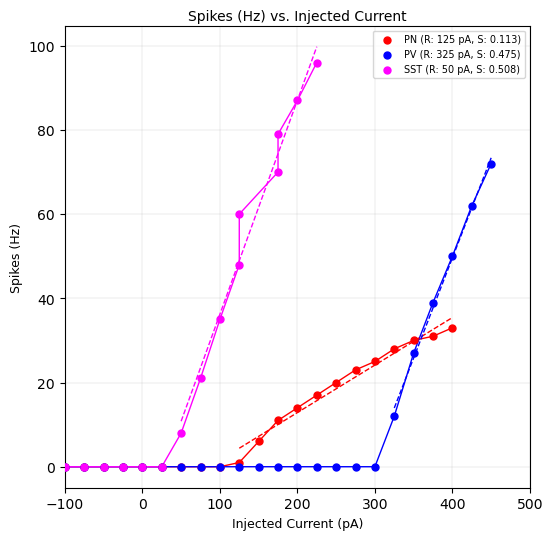

In [91]:
data_plot = ["PN", "PV", "SST"]
# data_plot = ['SST']
plot_AP_metrics_multi(
    datasets,
    freq_hz       = data_plot,
    xlim=(-100, 500),
    fit=True
)